In [1]:
import pandas as pd
import numpy as np
import zipfile

zip_path = "preprocessed_data1.zip"

with zipfile.ZipFile(zip_path, "r") as z:
    with z.open("preprocessed_data1.csv") as f:
        prep_df = pd.read_csv(f)

print(prep_df.shape)

(39119, 12)


In [2]:
prep_df1 = prep_df[prep_df['preamble'].notna() & prep_df['description'].notna() & prep_df['sentence'].notna()]
prep_df1.shape

(39119, 12)

In [3]:
df_with_marking = pd.read_csv("df_with_marking_final.csv")
df_with_marking

,id,region,entryDate,names,judge,decision,accused,articles,link_text,gender_accused,...,preamble,description,sentence,victim_count,killer_count,extracted_prison_term,prison_term_re,num_victims,has_woman_victim,has_man_victim
0,57844,29,2018-05-11,Газизов Дмитрий Рустамович - ст.105 ч.1 УК РФ,Аршинов Алексей Александрович,Вынесен ПРИГОВОР,Газизов Дмитрий Рустамович,ст.105 ч.1,http://lomonosovsky--arh.sudrf.ru/modules.php?...,мужчина,...,Дело <№> (29RS0<№>-58)\nПРИГОВОР\nименем Росси...,УСТАНОВИЛ:\nГ.Д.Р. совершил убийство при следу...,ПРИГОВОРИЛ:\nГ.Д.Р. признать виновным в соверш...,1,1,NaN,6.0,1,0,1
1,71745,23,2019-08-26,"Жмурко Юрий Геннадьевич - ст.167 ч.1, ст.105 ч...",Сапега Н.Н.,Вынесен ПРИГОВОР,Жмурко Юрий Геннадьевич,"ст.167 ч.1, ст.105 ч.1",http://novopokrovsky--krd.sudrf.ru/modules.php...,мужчина,...,К делу № 1-141/2019 г.\nПРИГОВОР\nИменем Росси...,"УСТАНОВИЛ:\nЖмурко Ю.Г. совершил убийство, т.е...",ПРИГОВОРИЛ:\nПризнать Жмурко Юрия Геннадьевича...,1,1,NaN,8.0,1,0,1
2,41579,50,2017-06-30,"Скворцов Евгений Владимирович - ст.325 ч.1, ст...",Мядзелец О.А.,Вынесен ПРИГОВОР,"Скворцов Евгений Владимирович, Скородумов Серг...","ст.325 ч.1, ст.325 ч.1, ст.325 ч.2, ст.162 ч.4...",http://oblsud--mo.sudrf.ru/modules.php?name=su...,"['мужчина', 'мужчина']",...,ПРИГОВОР\nИМЕНЕМ РОССИЙСКОЙ ФЕДЕРАЦИИ\n25 дека...,УСТАНОВИЛ:\nВердиктом коллегии присяжных засед...,ПРИГОВОРИЛ:\nСкородумова Сергея Юрьевича призн...,2,2,NaN,2017.0,2,1,0
3,116462,50,2022-05-04,"Матвеев Сергей Владимирович - ст. 30 ч.3, ст.1...",Перминова Е.А.,Вынесен ПРИГОВОР,Матвеев Сергей Владимирович,"ст. 30 ч.3, ст.105 ч.1",http://volokolamsk--mo.sudrf.ru/modules.php?na...,мужчина,...,Решение по уголовному делу\nИнформация по делу...,УСТАНОВИЛ:\nМатвеев С.В. совершил умышленное п...,ПРИГОВОРИЛ:\nпризнать виновным в совершении пр...,1,1,NaN,3.0,1,0,1
4,102232,38,2021-04-19,Шамов Сергей Викторович - ст.105 ч.1 УК РФ,Иванов Д.В.,Вынесен ПРИГОВОР,Шамов Сергей Викторович,ст.105 ч.1,http://angarsky--irk.sudrf.ru/modules.php?name...,мужчина,...,ПРИГОВОР\nИМЕНЕМ РОССИЙСКОЙ ФЕДЕРАЦИИ\nг.Ангар...,У С Т А Н О В И Л:\nНа основании вердикта колл...,ПРИГОВОРИЛ:\nПризнать Ш.С.В. виновным в соверш...,1,1,9.25,9.0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,122495,78,2022-03-01,"ТАРАКАНОВ ВЛАДИМИР ВЛАДИМИРОВИЧ - ст. 30 ч.3, ...",Гулевич Станислав Анатольевич,Вынесен ПРИГОВОР,Тараканов Владимир Владимирович,"ст. 30 ч.3, ст.105 ч.1",http://nvs--spb.sudrf.ru/modules.php?name=sud_...,мужчина,...,Дело № 1-589/22 (78 BS 0015-01-2022-00231414)\...,У С Т А Н О В И Л :\nПодсудимый Тараканов В.В....,П Р И Г О В О Р И Л :\nПризнать Тараканова Вла...,1,1,NaN,4.0,1,0,1
96,79171,60,2018-12-04,Немтинов Сергей Викторович - ст.105 ч.1 УК РФ,Сергеева Надежда Николаевна,Вынесен ПРИГОВОР,Немтинов Сергей Викторович,ст.105 ч.1,http://pskovsky--psk.sudrf.ru/modules.php?name...,мужчина,...,Дело ***\nПРИГОВОР\nИМЕНЕМ РОССИЙСКОЙ ФЕДЕРАЦИ...,"УСТАНОВИЛ:\nНемтинов С.В. совершил убийство, т...",ПРИГОВОРИЛ:\nПризнать Немтинова Сергея Викторо...,1,1,NaN,2019.0,1,1,0
97,31607,24,2017-07-31,Баженов Дмитрий Викторович - ст.105 ч.1 УК РФ,Безрукова Ольга Васильевна,Вынесен ПРИГОВОР,Баженов Дмитрий Викторович,ст.105 ч.1,http://igarka--krk.sudrf.ru/modules.php?name=s...,мужчина,...,Дело №\nП Р И Г О В О Р\nИменем Российской Фед...,У С Т А Н О В И Л:\nБаженов Д.В. совершил убий...,П Р И Г О В О Р И Л:\nБаженова Д.В. признать в...,1,1,NaN,2017.0,1,1,0
98,14640,50,2016-01-11,Меликян Тарон Акопи - ст.105 ч.1 УК РФ,Попова Марина Николаевна,Вынесен ПРИГОВОР,Меликян Тарон Акопи,ст.105 ч.1,http://luberetzy--mo.sudrf.ru/modules.php?name...,мужчина,...,Дело №\nПРИГОВОР\nименем Российской Федерации\...,"УСТАНОВИЛ:\nМеликян Т.А. совершил убийство, то...",ПРИГОВОРИЛ:\nМеликяна Т. А. признать виновным ...,1,1,NaN,8.0,1,1,0


In [190]:
import re

def count_killers(names_text: str) -> int:
    text = names_text.replace('\n', ' ').replace('\r', ' ').strip()

    people = re.split(r'\s*,\s*(?=[^,]*?\s*-\s*ст\.)', text)

    count = 0
    for person in people:
        # print(person)
        if '105' in person:
            count += 1
    # print("end")
    return count

In [5]:
df_with_marking['killer_count'] = df_with_marking['names'].apply(count_killers)

In [6]:
df_with_marking.columns

Index(['id', 'region', 'entryDate', 'names', 'judge', 'decision', 'accused',
       'articles', 'link_text', 'gender_accused', 'alcohol', 'drugs',
       'mental_disorder', 'prior_convictions', 'gender_victim',
       'relationship_between_accused_and_victim', 'time_of_day', 'day_of_week',
       'season', 'year', 'crime_region', 'location', 'method', 'cruelty',
       'intentional', 'motive', 'witnesses', 'precrime_argument',
       'prison_term', 'preamble', 'description', 'sentence', 'victim_count',
       'killer_count', 'extracted_prison_term', 'prison_term_re',
       'num_victims', 'has_woman_victim', 'has_man_victim'],
      dtype='object')

In [7]:
# import pandas as pd
# import numpy as np
# import zipfile

# zip_path = "sampled_data.zip"

# with zipfile.ZipFile(zip_path, "r") as z:
#     with z.open("sampled_data.csv") as f:
#         df_3000 = pd.read_csv(f)

# print(df_3000.shape)
df_3000 = pd.read_csv('3k_2.csv')

In [8]:
df_3000.columns

Index(['id', 'region', 'entryDate', 'names', 'judge', 'decision', 'accused',
       'articles', 'link_text', 'preamble', 'description', 'sentence',
       'killer_count', 'combined_text', 'predictions', 'predicted_gender',
       'predicted_prior_convictions', 'predicted_prison_term', 'predictions2',
       'predicted_alcohol', 'predicted_precrime_argument', 'predicted_motive',
       'predicted_relationship', 'predicted_has_woman_victim',
       'predicted_has_man_victim'],
      dtype='object')

In [9]:
df_no_marking = prep_df[(~prep_df['id'].isin(df_with_marking['id'])) & (~prep_df['id'].isin(df_3000['id']))]
df_no_marking.shape

(36019, 12)

# Предобработка

In [10]:
df_3000 = df_3000[~df_3000['id'].isin(df_with_marking['id'])]
df_3000.shape

(3000, 25)

In [11]:
full_df = df_no_marking.sample(n=7000, random_state=42)
full_df = pd.concat([full_df, df_with_marking, df_3000])
full_df.shape

(10100, 51)

In [12]:
# df_with_marking1 = full_df[full_df['id'].isin(df_with_marking['id'])]
# df_with_marking1.shape

In [15]:
from wordcloud import WordCloud

def draw_wordcloud(texts, max_words=1000, width=1000, height=500):
    wordcloud = WordCloud(background_color='white', max_words=max_words,
                          width=width, height=height)

    joint_texts = ' '.join(list(texts))
    wordcloud.generate(joint_texts)
    return wordcloud.to_image()

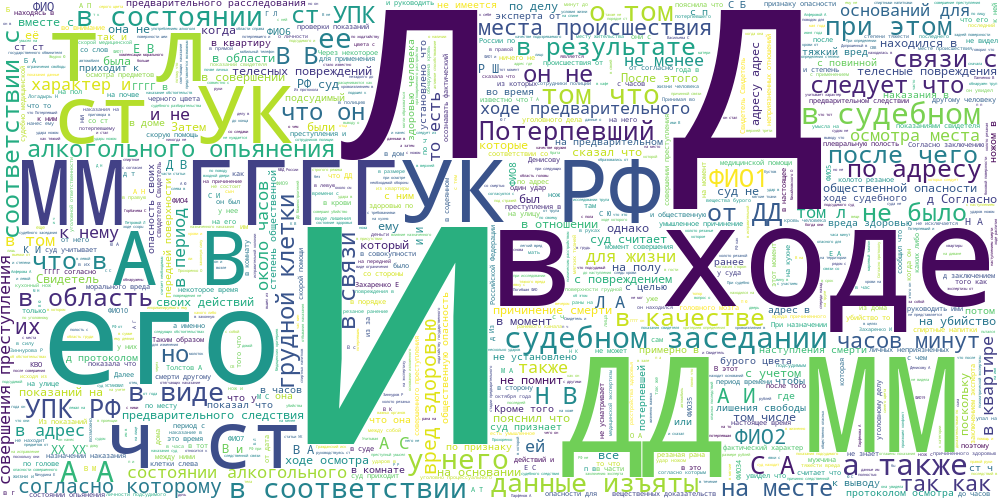

In [14]:
draw_wordcloud(df_with_marking.description)

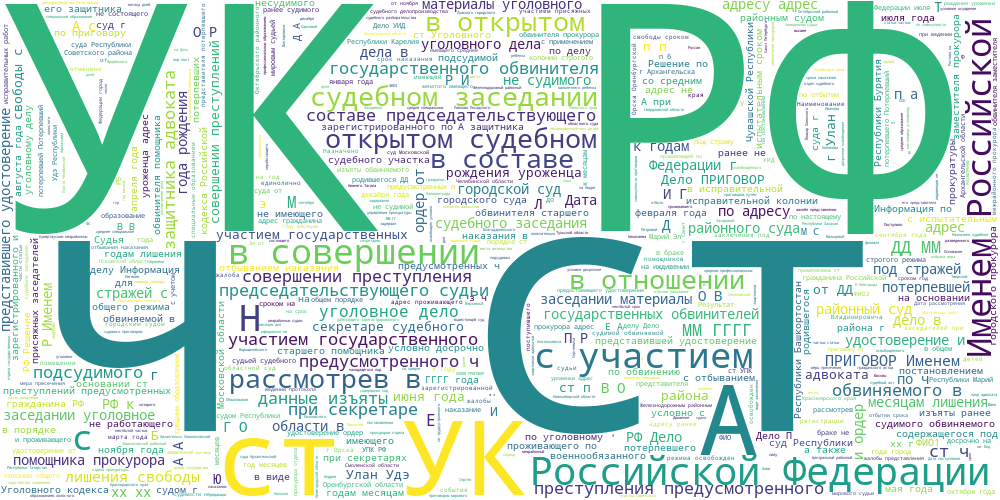

In [16]:
draw_wordcloud(df_with_marking.preamble)

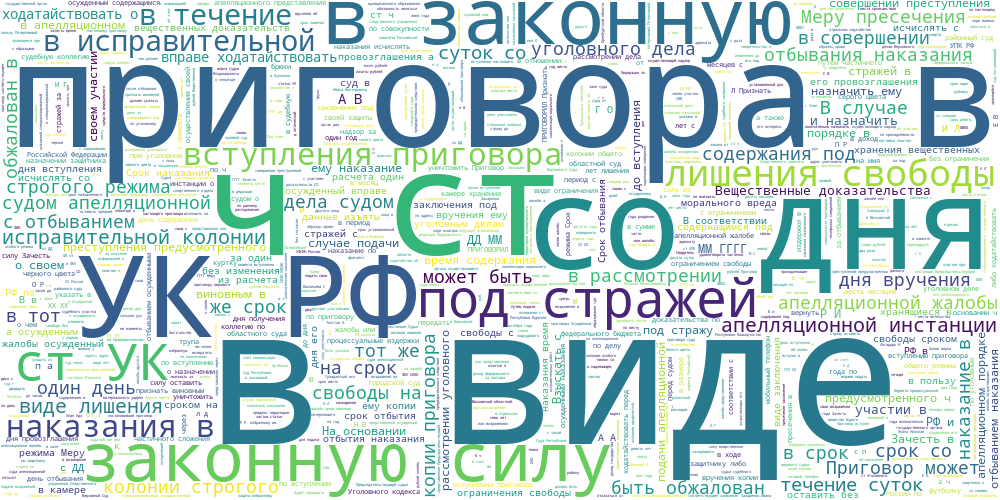

In [17]:
draw_wordcloud(df_with_marking.sentence)

In [12]:
import re
import pymorphy3
from nltk.corpus import stopwords
import nltk
from tqdm import tqdm
from functools import lru_cache

nltk.download("stopwords")
custom_stopwords = set([
    "в", "мм", "гггг", "дд", "ук", "рф", "ст", "д", "и", "ч", "ходе", "т", "л"
])

all_stopwords = set(stopwords.words("russian")).union(custom_stopwords)
morph = pymorphy3.MorphAnalyzer()

@lru_cache(maxsize=100000)
def lemmatize_word(word):
    return morph.parse(word)[0].normal_form

def preprocess_text(text):
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    text = text.lower()
    words = text.split()
    
    lemmas = [lemmatize_word(word) for word in words if word not in all_stopwords]
    return " ".join(lemmas)

tqdm.pandas()
full_df["tfidf_description_prep"] = full_df["description"].astype(str).progress_apply(preprocess_text)
full_df["tfidf_preamble_prep"] = full_df["preamble"].astype(str).progress_apply(preprocess_text)
full_df["tfidf_sentence_prep"] = full_df["sentence"].astype(str).progress_apply(preprocess_text)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Zephyrus\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
100%|██████████| 10100/10100 [00:05<00:00, 1933.50it/s]


In [13]:
import re
import pymorphy3
from nltk.corpus import stopwords
import nltk
from tqdm import tqdm

nltk.download("stopwords")
custom_stopwords = set([
    "в", "мм", "гггг", "дд", "ук", "рф", "ст", "д", "и", "ч", "ходе", "т", "л"
])

all_stopwords = set(stopwords.words("russian")).union(custom_stopwords)
morph = pymorphy3.MorphAnalyzer()

def lemmatize_word(word):
    return morph.parse(word)[0].normal_form

def preprocess_text(text):
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    text = text.lower()
    return text

tqdm.pandas()
full_df["tfidf_description_prep_no_lemma"] = full_df["description"].astype(str).progress_apply(preprocess_text)
full_df["tfidf_preamble_prep_no_lemma"] = full_df["preamble"].astype(str).progress_apply(preprocess_text)
full_df["tfidf_sentence_prep_no_lemma"] = full_df["sentence"].astype(str).progress_apply(preprocess_text)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Zephyrus\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
100%|██████████| 10100/10100 [00:01<00:00, 6347.60it/s]


In [14]:
def preprocess_text_w2v(text):
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    text = text.lower()

    words = text.split()
    return [word for word in words if word not in all_stopwords and len(word) > 1]

tqdm.pandas()
full_df["w2v_description_prep"] = full_df["description"].astype(str).progress_apply(preprocess_text_w2v)
full_df["w2v_preamble_prep"] = full_df["preamble"].astype(str).progress_apply(preprocess_text_w2v)
full_df["w2v_sentence_prep"] = full_df["sentence"].astype(str).progress_apply(preprocess_text_w2v)

100%|██████████| 10100/10100 [00:02<00:00, 4475.60it/s]


In [18]:
extracted_features = ["gender_accused", "alcohol", "drugs", "prior_convictions",
    "relationship_between_accused_and_victim",
    "time_of_day", "location",
    "method", "motive",
    "precrime_argument", "prison_term", "has_woman_victim", "has_man_victim"]
len(extracted_features)

13

In [19]:
description_features = ["gender_accused", "alcohol", "drugs",
                        "relationship_between_accused_and_victim", 
                        "time_of_day", "location", "method", "motive", "precrime_argument", "has_woman_victim", "has_man_victim"]
sentence_features = ["prison_term"]

preamble_desctiption_features = ["prior_convictions"]

len(description_features), len(sentence_features), len(preamble_desctiption_features)

(11, 1, 1)

In [20]:
features_accused = ["gender_accused", "alcohol", "drugs", 
                    "prior_convictions", "relationship_between_accused_and_victim", "prison_term"]

features_victim = ["has_woman_victim", "has_man_victim"]

features_common = ["time_of_day",
                    "location", "method", "motive", "precrime_argument"]

len(features_accused), len(features_victim), len(features_common)

(6, 2, 5)

In [21]:
df_with_marking1 = full_df[full_df['id'].isin(df_with_marking['id'])]
df_with_marking1.shape

(100, 60)

In [22]:
df_gold_ = df_with_marking1[df_with_marking1["killer_count"] == 1]
df_gold_.shape

(97, 60)

In [23]:
# for col in features_accused:
#     print(df_gold_[col].value_counts())
#     print()

In [23]:
full_df['killer_count'] = full_df['names'].apply(count_killers)
full_df1 = full_df[full_df["killer_count"] == 1]
full_df1.shape

(9846, 60)

In [24]:
df_weak = full_df1[full_df1['id'].isin(df_3000['id'])]
df_weak.shape

(3000, 60)

In [25]:
df_weak1 = df_weak[df_weak["killer_count"] == 1]
df_weak1.shape

(3000, 60)

In [29]:
from sklearn.model_selection import train_test_split

df_train_, df_temp = train_test_split(df_weak, test_size=0.3, random_state=42)
df_val_, df_test_ = train_test_split(df_temp, test_size=0.5, random_state=42)

df_train_.shape, df_val_.shape, df_test_.shape

((2100, 60), (450, 60), (450, 60))

In [184]:
from sklearn.feature_extraction.text import TfidfVectorizer
from gensim.models import Word2Vec

def average_word_vectors(tokens_list, model, vector_size):
    vectors = [model.wv[word] for word in tokens_list if word in model.wv]
    if len(vectors) == 0:
        return np.zeros(vector_size)
    return np.mean(vectors, axis=0)

def getX_trainVal(col, df_train, df_val, df_test, full_df_for_vectorizer, vectorizer_name="tfidf", lemmatized=False, trial=None):
    full_df_for_vectorizer = full_df_for_vectorizer[(~full_df_for_vectorizer['id'].isin(df_val['id'])) & (~full_df_for_vectorizer['id'].isin(df_test['id'])) & (~full_df_for_vectorizer['id'].isin(df_gold_['id']))]
    
    if vectorizer_name == "tfidf":
        max_df = trial.suggest_float('max_df', 0.5, 1.0)
        min_df = trial.suggest_int('min_df', 1, 20)
        max_features = trial.suggest_int('max_features', 500, 2000)

        if lemmatized:
            vectorizer = TfidfVectorizer(max_df=max_df,
                                        min_df=min_df,
                                        max_features=max_features)
            vectorizer.fit(full_df_for_vectorizer["tfidf_preamble_prep"] + full_df_for_vectorizer["tfidf_description_prep"] + full_df_for_vectorizer["tfidf_sentence_prep"])

            if col in ['predicted_gender', 'predicted_prior_convictions', 'predicted_prison_term']:
                X_train_ = vectorizer.transform(df_train["tfidf_preamble_prep"] + df_train["tfidf_sentence_prep"])
                X_val_ = vectorizer.transform(df_val["tfidf_preamble_prep"] + df_val["tfidf_sentence_prep"])
                return X_train_, X_val_
            
            if col in ['predicted_alcohol', 'predicted_precrime_argument', 'predicted_motive', 'predicted_relationship', 'predicted_relationship_grouped', 'predicted_has_woman_victim', 'predicted_has_man_victim']:
                X_train_ = vectorizer.transform(df_train["tfidf_description_prep"])
                X_val_ = vectorizer.transform(df_val["tfidf_description_prep"])
                return X_train_, X_val_

            # if col in description_features:
            #     X_train_ = vectorizer.transform(df_train["tfidf_description_prep"])
            #     X_val_ = vectorizer.transform(df_val["tfidf_description_prep"])
            #     return X_train_, X_val_
            
            # elif col in preamble_desctiption_features:
            #     X_train_ = vectorizer.transform(df_train["tfidf_preamble_prep"] + df_train["tfidf_description_prep"])
            #     X_val_ = vectorizer.transform(df_val["tfidf_preamble_prep"] + df_val["tfidf_description_prep"])
            #     return X_train_, X_val_
            
            # elif col in sentence_features:
            #     X_train_ = vectorizer.transform(df_train["tfidf_sentence_prep"])
            #     X_val_ = vectorizer.transform(df_val["tfidf_sentence_prep"])
            #     return X_train_, X_val_
            
       
        elif not lemmatized:
            vectorizer = TfidfVectorizer(max_df=max_df,
                                        min_df=min_df,
                                        max_features=max_features)
            vectorizer.fit(full_df_for_vectorizer["tfidf_preamble_prep_no_lemma"] + full_df_for_vectorizer["tfidf_description_prep_no_lemma"] + full_df_for_vectorizer["tfidf_sentence_prep_no_lemma"])

            if col in ['predicted_gender', 'predicted_prior_convictions', 'predicted_prison_term']:
                X_train_ = vectorizer.transform(df_train["tfidf_preamble_prep_no_lemma"] + df_train["tfidf_sentence_prep_no_lemma"])
                X_val_ = vectorizer.transform(df_val["tfidf_preamble_prep_no_lemma"] + df_val["tfidf_sentence_prep_no_lemma"])
                return X_train_, X_val_
            
            if col in ['predicted_alcohol', 'predicted_precrime_argument', 'predicted_motive', 'predicted_relationship', 'predicted_relationship_grouped', 'predicted_has_woman_victim', 'predicted_has_man_victim']:
                X_train_ = vectorizer.transform(df_train["tfidf_description_prep_no_lemma"])
                X_val_ = vectorizer.transform(df_val["tfidf_description_prep_no_lemma"])
                return X_train_, X_val_
            
            # if col in description_features:
            #     X_train_ = vectorizer.transform(df_train["tfidf_description_prep_no_lemma"])
            #     X_val_ = vectorizer.transform(df_val["tfidf_description_prep_no_lemma"])
            #     return X_train_, X_val_
            
            # elif col in preamble_desctiption_features:
            #     X_train_ = vectorizer.transform(df_train["tfidf_preamble_prep_no_lemma"] + df_train["tfidf_description_prep_no_lemma"])
            #     X_val_ = vectorizer.transform(df_val["tfidf_preamble_prep_no_lemma"] + df_val["tfidf_description_prep_no_lemma"])
            #     return X_train_, X_val_
            
            # elif col in sentence_features:
            #     X_train_ = vectorizer.transform(df_train["tfidf_sentence_prep_no_lemma"])
            #     X_val_ = vectorizer.transform(df_val["tfidf_sentence_prep_no_lemma"])
            #     return X_train_, X_val_

    if vectorizer_name == "word2vec":
        vector_size = trial.suggest_int("w2v_vector_size", 100, 300)
        window = trial.suggest_int("w2v_window", 2, 8)
        min_count = trial.suggest_int("w2v_min_count", 1, 3)
        
        sentences = list(full_df_for_vectorizer["w2v_preamble_prep"]) + \
                    list(full_df_for_vectorizer["w2v_description_prep"]) + \
                    list(full_df_for_vectorizer["w2v_sentence_prep"])

        w2v_model = Word2Vec(sentences=sentences, vector_size=vector_size,
                         window=window, min_count=min_count, workers=4, seed=42)

        vector_size = w2v_model.vector_size

        if col in ['predicted_gender', 'predicted_prior_convictions', 'predicted_prison_term']:
            X_train_ = np.vstack(
                (df_train["w2v_preamble_prep"] + df_train["w2v_sentence_prep"]).apply(lambda x: average_word_vectors(x, w2v_model, vector_size))
            )
            X_val_ = np.vstack(
                (df_val["w2v_preamble_prep"] + df_val["w2v_sentence_prep"]).apply(lambda x: average_word_vectors(x, w2v_model, vector_size))
            )
            return X_train_, X_val_
        
        if col in ['predicted_alcohol', 'predicted_precrime_argument', 'predicted_motive', 'predicted_relationship', 'predicted_relationship_grouped', 'predicted_has_woman_victim', 'predicted_has_man_victim']:
            X_train_ = np.vstack(df_train["w2v_description_prep"].apply(lambda x: average_word_vectors(x, w2v_model, vector_size)))
            X_val_ = np.vstack(df_val["w2v_description_prep"].apply(lambda x: average_word_vectors(x, w2v_model, vector_size)))
            return X_train_, X_val_ 

        # if col in description_features:
        #     X_train_ = np.vstack(df_train["w2v_description_prep"].apply(lambda x: average_word_vectors(x, w2v_model, vector_size)))
        #     X_val_ = np.vstack(df_val["w2v_description_prep"].apply(lambda x: average_word_vectors(x, w2v_model, vector_size)))
        #     return X_train_, X_val_
        
        # elif col in preamble_desctiption_features:
        #     X_train_ = np.vstack(
        #         (df_train["w2v_preamble_prep"] + df_train["w2v_description_prep"]).apply(lambda x: average_word_vectors(x, w2v_model, vector_size))
        #     )
        #     X_val_ = np.vstack(
        #         (df_val["w2v_preamble_prep"] + df_val["w2v_description_prep"]).apply(lambda x: average_word_vectors(x, w2v_model, vector_size))
        #     )
        #     return X_train_, X_val_
        
        # elif col in sentence_features:
        #     X_train_ = np.vstack(df_train["w2v_sentence_prep"].apply(lambda x: average_word_vectors(x, w2v_model, vector_size)))
        #     X_val_ = np.vstack(df_val["w2v_sentence_prep"].apply(lambda x: average_word_vectors(x, w2v_model, vector_size)))
        #     return X_train_, X_val_

In [185]:
from sklearn.feature_extraction.text import TfidfVectorizer
from gensim.models import Word2Vec
import os
import joblib

def average_word_vectors(tokens_list, model, vector_size):
    vectors = [model.wv[word] for word in tokens_list if word in model.wv]
    if len(vectors) == 0:
        return np.zeros(vector_size)
    return np.mean(vectors, axis=0)

def getX_trainTest(col, df_train, df_val, df_test, full_df_for_vectorizer, vectorizer_name="tfidf", lemmatized=False, best_params=None, save=False, save_path="saved_models"):
    if df_val is not None:
        full_df_for_vectorizer = full_df_for_vectorizer[(~full_df_for_vectorizer['id'].isin(df_val['id'])) & (~full_df_for_vectorizer['id'].isin(df_test['id'])) & (~full_df_for_vectorizer['id'].isin(df_gold_['id']))]
    else:
        full_df_for_vectorizer = full_df_for_vectorizer[(~full_df_for_vectorizer['id'].isin(df_test['id'])) & (~full_df_for_vectorizer['id'].isin(df_gold_['id']))]

    if vectorizer_name == "tfidf":
        max_df = best_params['max_df']
        min_df = best_params['min_df']
        max_features = best_params['max_features']

        if lemmatized:
            vectorizer = TfidfVectorizer(max_df=max_df,
                                        min_df=min_df,
                                        max_features=max_features)
            vectorizer.fit(full_df_for_vectorizer["tfidf_preamble_prep"] + full_df_for_vectorizer["tfidf_description_prep"] + full_df_for_vectorizer["tfidf_sentence_prep"])
            if save:
                tfidf_filename = f"{save_path}/vectorizer_{col}_{'lemma' if lemmatized else 'nolem'}.joblib"
                joblib.dump(vectorizer, tfidf_filename)

            if col in ['predicted_gender', 'predicted_prior_convictions', 'predicted_prison_term']:
                X_train_ = vectorizer.transform(df_train["tfidf_preamble_prep"] + df_train["tfidf_sentence_prep"])
                X_test_ = vectorizer.transform(df_test["tfidf_preamble_prep"] + df_test["tfidf_sentence_prep"])
                return X_train_, X_test_
            
            if col in ['predicted_alcohol', 'predicted_precrime_argument', 'predicted_motive', 'predicted_relationship', 'predicted_relationship_grouped', 'predicted_has_woman_victim', 'predicted_has_man_victim']:
                X_train_ = vectorizer.transform(df_train["tfidf_description_prep"])
                X_test_ = vectorizer.transform(df_test["tfidf_description_prep"])
                return X_train_, X_test_

            # if col in description_features:
            #     X_train_ = vectorizer.transform(df_train["tfidf_description_prep"])
            #     X_test_ = vectorizer.transform(df_test["tfidf_description_prep"])
            #     return X_train_, X_test_
            
            # elif col in preamble_desctiption_features:
            #     X_train_ = vectorizer.transform(df_train["tfidf_preamble_prep"] + df_train["tfidf_description_prep"])
            #     X_test_ = vectorizer.transform(df_test["tfidf_preamble_prep"] + df_test["tfidf_description_prep"])
            #     return X_train_, X_test_
            
            # elif col in sentence_features:
            #     X_train_ = vectorizer.transform(df_train["tfidf_sentence_prep"])
            #     X_test_ = vectorizer.transform(df_test["tfidf_sentence_prep"])
            #     return X_train_, X_test_

        elif not lemmatized:
            vectorizer = TfidfVectorizer(max_df=max_df,
                                        min_df=min_df,
                                        max_features=max_features)
            vectorizer.fit(full_df_for_vectorizer["tfidf_preamble_prep_no_lemma"] + full_df_for_vectorizer["tfidf_description_prep_no_lemma"] + full_df_for_vectorizer["tfidf_sentence_prep_no_lemma"])
            if save:
                tfidf_filename = f"{save_path}/vectorizer_{col}_{'lemma' if lemmatized else 'nolem'}.joblib"
                joblib.dump(vectorizer, tfidf_filename)

            if col in ['predicted_gender', 'predicted_prior_convictions', 'predicted_prison_term']:
                X_train_ = vectorizer.transform(df_train["tfidf_preamble_prep_no_lemma"] + df_train["tfidf_sentence_prep_no_lemma"])
                X_test_ = vectorizer.transform(df_test["tfidf_preamble_prep_no_lemma"] + df_test["tfidf_sentence_prep_no_lemma"])
                return X_train_, X_test_
            
            if col in ['predicted_alcohol', 'predicted_precrime_argument', 'predicted_motive', 'predicted_relationship', 'predicted_relationship_grouped', 'predicted_has_woman_victim', 'predicted_has_man_victim']:
                X_train_ = vectorizer.transform(df_train["tfidf_description_prep_no_lemma"])
                X_test_ = vectorizer.transform(df_test["tfidf_description_prep_no_lemma"])
                return X_train_, X_test_
            
            # if col in description_features:
            #     X_train_ = vectorizer.transform(df_train["tfidf_description_prep_no_lemma"])
            #     X_test_ = vectorizer.transform(df_test["tfidf_description_prep_no_lemma"])
            #     return X_train_, X_test_
            
            # elif col in preamble_desctiption_features:
            #     X_train_ = vectorizer.transform(df_train["tfidf_preamble_prep_no_lemma"] + df_train["tfidf_description_prep_no_lemma"])
            #     X_test_ = vectorizer.transform(df_test["tfidf_preamble_prep_no_lemma"] + df_test["tfidf_description_prep_no_lemma"])
            #     return X_train_, X_test_
            
            # elif col in sentence_features:
            #     X_train_ = vectorizer.transform(df_train["tfidf_sentence_prep_no_lemma"])
            #     X_test_ = vectorizer.transform(df_test["tfidf_sentence_prep_no_lemma"])
            #     return X_train_, X_test_

    if vectorizer_name == "word2vec":
        vector_size = best_params['w2v_vector_size']
        window = best_params['w2v_window']
        min_count = best_params['w2v_min_count']
        
        sentences = list(full_df_for_vectorizer["w2v_preamble_prep"]) + \
                    list(full_df_for_vectorizer["w2v_description_prep"]) + \
                    list(full_df_for_vectorizer["w2v_sentence_prep"])

        w2v_model = Word2Vec(sentences=sentences, vector_size=vector_size,
                         window=window, min_count=min_count, workers=4, seed=42)
        if save:
            w2v_filename = f"{save_path}/word2vec_model_{col}.model"
            w2v_model.save(w2v_filename)

        vector_size = w2v_model.vector_size

        if col in ['predicted_gender', 'predicted_prior_convictions', 'predicted_prison_term']:
            X_train_ = np.vstack(
                (df_train["w2v_preamble_prep"] + df_train["w2v_sentence_prep"]).apply(lambda x: average_word_vectors(x, w2v_model, vector_size))
            )
            X_test_ = np.vstack(
                (df_test["w2v_preamble_prep"] + df_test["w2v_sentence_prep"]).apply(lambda x: average_word_vectors(x, w2v_model, vector_size))
            )
            return X_train_, X_test_
        
        if col in ['predicted_alcohol', 'predicted_precrime_argument', 'predicted_motive', 'predicted_relationship', 'predicted_relationship_grouped', 'predicted_has_woman_victim', 'predicted_has_man_victim']:
            X_train_ = np.vstack(df_train["w2v_description_prep"].apply(lambda x: average_word_vectors(x, w2v_model, vector_size)))
            X_test_ = np.vstack(df_test["w2v_description_prep"].apply(lambda x: average_word_vectors(x, w2v_model, vector_size)))
            return X_train_, X_test_

        # if col in description_features:
        #     X_train_ = np.vstack(df_train["w2v_description_prep"].apply(lambda x: average_word_vectors(x, w2v_model, vector_size)))
        #     X_test_ = np.vstack(df_test["w2v_description_prep"].apply(lambda x: average_word_vectors(x, w2v_model, vector_size)))
        #     return X_train_, X_test_
        
        # elif col in preamble_desctiption_features:
        #     X_train_ = np.vstack(
        #         (df_train["w2v_preamble_prep"] + df_train["w2v_description_prep"]).apply(lambda x: average_word_vectors(x, w2v_model, vector_size))
        #     )
        #     X_test_ = np.vstack(
        #         (df_test["w2v_preamble_prep"] + df_test["w2v_description_prep"]).apply(lambda x: average_word_vectors(x, w2v_model, vector_size))
        #     )
        #     return X_train_, X_test_
        
        # elif col in sentence_features:
        #     X_train_ = np.vstack(df_train["w2v_sentence_prep"].apply(lambda x: average_word_vectors(x, w2v_model, vector_size)))
        #     X_test_ = np.vstack(df_test["w2v_sentence_prep"].apply(lambda x: average_word_vectors(x, w2v_model, vector_size)))
        #     return X_train_, X_test_

In [30]:
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from scipy.sparse import issparse

def train_and_validate(
    col,
    lemmatized=False,
    vectorizer_name="tfidf",
    model_name="catboost",
    use_balancing=False,
    trial=None,
):
    X_train_col, X_val_col = getX_trainVal(col=col, df_train=df_train_, df_val=df_val_, df_test=df_test_, full_df_for_vectorizer=full_df1, vectorizer_name=vectorizer_name, lemmatized=lemmatized, trial=trial)   

    y_train = df_train_[col]
    y_val = df_val_[col]

    # print(1)

    if y_train.nunique() > 2:
        loss = "MultiClass"
    else:
        loss = "Logloss"

    def get_model():
        if model_name == "catboost":
            return CatBoostClassifier(
                iterations=trial.suggest_int("iterations", 100, 300),
                depth=trial.suggest_int("depth", 3, 7),
                learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
                loss_function=loss,
                verbose=False,
                auto_class_weights="Balanced" if use_balancing else None,
                random_state=42,
            )

        elif model_name == "random_forest":
            return RandomForestClassifier(
                n_estimators=trial.suggest_int("n_estimators", 100, 300),
                max_depth=trial.suggest_int("max_depth", 5, 50),
                min_samples_split=trial.suggest_int("min_samples_split", 2, 10),
                min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 10),
                class_weight="balanced" if use_balancing else None,
                random_state=42,
                n_jobs=-1,
            )

    # print(2)
    model = get_model()
    if model_name == "catboost":
        model.fit(X_train_col, y_train)
    else:
        X_train_input = X_train_col.toarray() if issparse(X_train_col) else X_train_col
        model.fit(X_train_input, y_train)
    
    # print(3)

    X_val_input = X_val_col.toarray() if issparse(X_val_col) else X_val_col
    y_pred = model.predict(X_val_input)

    f1 = precision_recall_fscore_support(y_val, y_pred, average="weighted", zero_division=0)[2]
    # print(f'f1 = {f1}')
    return f1

In [31]:
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from scipy.sparse import issparse
import joblib
import os

def train_and_test(
    col,
    best_params,
    lemmatized=False,
    vectorizer_name="tfidf",
    model_name="catboost",
    use_balancing=False,
    df_train1=None,
    df_val1=None,
    df_test1=None,
    save=False,
    save_path="saved_models"
):
    if save:
        X_train_col, X_test_col = getX_trainTest(col=col, df_train=df_train1, df_val=df_val1, df_test=df_test1, full_df_for_vectorizer=full_df1, vectorizer_name=vectorizer_name, lemmatized=lemmatized, best_params=best_params, save=True, save_path="saved_models")     
    else:
        X_train_col, X_test_col = getX_trainTest(col=col, df_train=df_train1, df_val=df_val1, df_test=df_test1, full_df_for_vectorizer=full_df1, vectorizer_name=vectorizer_name, lemmatized=lemmatized, best_params=best_params) 
    # print(col)
    metrics_list = []

    y_train = df_train1[col]
    y_test = df_test1[col]

    # print(1)

    if y_train.nunique() > 2:
        loss = "MultiClass"
    else:
        loss = "Logloss"

    # print(4)
    def get_model():
        if model_name == "catboost":
            return CatBoostClassifier(
                iterations=best_params["iterations"],
                depth=best_params["depth"],
                learning_rate=best_params["learning_rate"],
                loss_function=loss,
                verbose=False,
                auto_class_weights="Balanced" if use_balancing else None,
                random_state=42,
            )

        elif model_name == "random_forest":
            return RandomForestClassifier(
                n_estimators=best_params["n_estimators"],
                max_depth=best_params["max_depth"],
                min_samples_split=best_params["min_samples_split"],
                min_samples_leaf=best_params["min_samples_leaf"],
                class_weight="balanced" if use_balancing else None,
                random_state=42,
                n_jobs=-1,
            )


    model = get_model()

    # print(2)
    if model_name == "catboost":
        model.fit(X_train_col, y_train)
    else:
        X_train_input = X_train_col.toarray() if issparse(X_train_col) else X_train_col
        model.fit(X_train_input, y_train)
    
    # print(3)
    if save:
        os.makedirs(save_path, exist_ok=True)
        model_filename = f"{save_path}/model_{col}_{model_name}_{vectorizer_name}_{'lemma' if lemmatized else 'nolem'}_{'bal' if use_balancing else 'nobal'}.joblib"
        joblib.dump(model, model_filename)

    X_test_input = X_test_col.toarray() if issparse(X_test_col) else X_test_col
    y_pred = model.predict(X_test_input)

    acc = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average="weighted", zero_division=0
    )

    metrics_list.append({
        "Feature": col,
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })
    print(f"accuracy = {acc}")

    metrics_df = pd.DataFrame(metrics_list)
    return metrics_df

In [32]:
from itertools import product
import optuna

def optimize_hyperparams(col, vect, model, lemm, balance, n_trials=20):
    def objective(trial):
        return train_and_validate(
            col=col,
            lemmatized=lemm,
            vectorizer_name=vect,
            model_name=model,
            use_balancing=balance,
            trial=trial,
        )
            
    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=n_trials)

    best_f1 = study.best_value
    best_params = study.best_params
    return best_f1, best_params

In [33]:
def full_grid_search_with_optuna(col, n_trials=20):
    vectorizer_options = ["tfidf", "word2vec"]
    model_options = ["catboost", "random_forest"]
    lemmatized_options = [False, True]
    balancing_options = [False, True]

    # vectorizer_options = ["tfidf"]
    # model_options = ["catboost"]
    # lemmatized_options = [False]
    # balancing_options = [False]

    best_result = {
        "Feature": col,
        "Best F1": -1,
        "Best Combo": None,
        "Best Params": None
    }

    results = []

    for vect, model, lemm, balance in product(
        vectorizer_options, model_options,
        lemmatized_options, balancing_options
    ):
        if vect == "word2vec" and lemm:
            continue

        print(f"\nТестируем: {vect}, {model}, lemm={lemm}, balance={balance}")

        f1_val, best_params = optimize_hyperparams(
            col, vect, model, lemm, balance, n_trials=n_trials
        )
        print(f"F1 (val) = {f1_val:.4f}, Best Params = {best_params}")

        metrics_df = train_and_test(
                    col,
                    best_params,
                    lemmatized=lemm,
                    vectorizer_name=vect,
                    model_name=model,
                    use_balancing=balance,
                    df_train1=df_train_,
                    df_val1=df_val_,
                    df_test1=df_test_,
                )

        f1_test = metrics_df['F1'].values[0]
        acc_test = metrics_df['Accuracy'].values[0]
        print(f"F1 test = {f1_test:.4f}, acc_test = {acc_test:.4f}")
                
        results.append({
            'Feature': col,
            'vectorizer': vect,
            'model': model,
            "lemmatized": lemm,
            "use_balancing": balance,
            'f1': f1_test,
            'accuracy': acc_test,
            'params': best_params
        })

        if f1_test > best_result["Best F1"]:
            best_result["Best F1"] = f1_test
            best_result["Best Combo"] = {
                "vectorizer": vect,
                "model": model,
                "lemmatized": lemm,
                "use_balancing": balance,
            }
            best_result["Best Params"] = best_params

    results_df = pd.DataFrame(results)
    return best_result, results_df

## Gender accused

In [34]:
df_weak.columns

Index(['id', 'region', 'entryDate', 'names', 'judge', 'decision', 'accused',
       'articles', 'link_text', 'preamble', 'description', 'sentence',
       'gender_accused', 'alcohol', 'drugs', 'mental_disorder',
       'prior_convictions', 'gender_victim',
       'relationship_between_accused_and_victim', 'time_of_day', 'day_of_week',
       'season', 'year', 'crime_region', 'location', 'method', 'cruelty',
       'intentional', 'motive', 'witnesses', 'precrime_argument',
       'prison_term', 'victim_count', 'killer_count', 'extracted_prison_term',
       'prison_term_re', 'num_victims', 'has_woman_victim', 'has_man_victim',
       'combined_text', 'predictions', 'predicted_gender',
       'predicted_prior_convictions', 'predicted_prison_term',
       'tfidf_description_prep', 'tfidf_preamble_prep', 'tfidf_sentence_prep',
       'tfidf_description_prep_no_lemma', 'tfidf_preamble_prep_no_lemma',
       'tfidf_sentence_prep_no_lemma', 'w2v_description_prep',
       'w2v_preamble_prep', 

In [35]:
df_weak['predicted_gender'].value_counts()

predicted_gender
мужчина                      2480
женщина                       485
мужчина, мужчина               13
неизвестно                      7
мужчина, женщина                5
мужчина, мужчина, мужчина       1
женщина, женщина                1
неизвестно, женщина             1
женщина, женщина, мужчина       1
Name: count, dtype: int64

In [36]:
df_weak_1_killer = df_weak.copy()
df_weak_1_killer['killer_count'] = df_weak_1_killer['names'].apply(count_killers)
df_weak_1_killer = df_weak_1_killer[df_weak_1_killer['killer_count'] == 1]

In [37]:
df_weak_1_killer['predicted_gender'].value_counts()

predicted_gender
мужчина                      2480
женщина                       485
мужчина, мужчина               13
неизвестно                      7
мужчина, женщина                5
мужчина, мужчина, мужчина       1
женщина, женщина                1
неизвестно, женщина             1
женщина, женщина, мужчина       1
Name: count, dtype: int64

In [38]:
df_weak_1_killer = df_weak_1_killer[df_weak_1_killer['predicted_gender'].isin(['мужчина', 'женщина'])]
df_weak_1_killer['predicted_gender'].value_counts()

predicted_gender
мужчина    2480
женщина     485
Name: count, dtype: int64

In [39]:
from sklearn.model_selection import train_test_split

df_train_, df_temp = train_test_split(df_weak_1_killer, test_size=0.3, random_state=42)
df_val_, df_test_ = train_test_split(df_temp, test_size=0.5, random_state=42)

df_train_.shape, df_val_.shape, df_test_.shape

((2075, 53), (445, 53), (445, 53))

In [40]:
df_train_['predicted_gender'].value_counts()

predicted_gender
мужчина    1723
женщина     352
Name: count, dtype: int64

In [41]:
df_val_['predicted_gender'].value_counts()

predicted_gender
мужчина    378
женщина     67
Name: count, dtype: int64

In [42]:
df_test_['predicted_gender'].value_counts()

predicted_gender
мужчина    379
женщина     66
Name: count, dtype: int64

In [43]:
# import gc

# gc.collect()

In [44]:
best, results = full_grid_search_with_optuna('predicted_gender', n_trials=5)
print("\nЛУЧШАЯ КОМБИНАЦИЯ:")
print(best)
results

[I 2025-04-23 22:32:48,600] A new study created in memory with name: no-name-a3a58b10-ba50-4ce5-8b04-34bf9bf99827



Тестируем: tfidf, catboost, lemm=False, balance=False


[I 2025-04-23 22:33:20,572] Trial 0 finished with value: 0.9841206321805374 and parameters: {'max_df': 0.5200641185682231, 'min_df': 13, 'max_features': 637, 'iterations': 223, 'depth': 6, 'learning_rate': 0.2868839167456247}. Best is trial 0 with value: 0.9841206321805374.
[I 2025-04-23 22:33:49,351] Trial 1 finished with value: 0.9954774988927549 and parameters: {'max_df': 0.9603003495924971, 'min_df': 17, 'max_features': 870, 'iterations': 203, 'depth': 5, 'learning_rate': 0.046080250947591266}. Best is trial 1 with value: 0.9954774988927549.
[I 2025-04-23 22:34:21,258] Trial 2 finished with value: 0.9931945566488017 and parameters: {'max_df': 0.8455903500096482, 'min_df': 15, 'max_features': 1341, 'iterations': 263, 'depth': 6, 'learning_rate': 0.017302778469602733}. Best is trial 1 with value: 0.9954774988927549.
[I 2025-04-23 22:34:49,354] Trial 3 finished with value: 0.9954774988927549 and parameters: {'max_df': 0.9201458696271367, 'min_df': 1, 'max_features': 1258, 'iterations'

F1 (val) = 0.9955, Best Params = {'max_df': 0.9603003495924971, 'min_df': 17, 'max_features': 870, 'iterations': 203, 'depth': 5, 'learning_rate': 0.046080250947591266}


[I 2025-04-23 22:35:44,172] A new study created in memory with name: no-name-a8b821e1-0be1-48a7-8ca2-244e4b20d809


...

[I 2025-04-23 23:27:27,613] A new study created in memory with name: no-name-ae13bcea-a91c-46a3-8cab-59144d205f8b


accuracy = 0.8876404494382022
F1 test = 0.8569, acc_test = 0.8876

Тестируем: word2vec, random_forest, lemm=False, balance=True


[I 2025-04-23 23:29:01,615] Trial 0 finished with value: 0.8786440202266058 and parameters: {'w2v_vector_size': 108, 'w2v_window': 2, 'w2v_min_count': 1, 'n_estimators': 179, 'max_depth': 18, 'min_samples_split': 7, 'min_samples_leaf': 8}. Best is trial 0 with value: 0.8786440202266058.
[I 2025-04-23 23:31:12,053] Trial 1 finished with value: 0.8831409678198501 and parameters: {'w2v_vector_size': 213, 'w2v_window': 8, 'w2v_min_count': 2, 'n_estimators': 125, 'max_depth': 17, 'min_samples_split': 8, 'min_samples_leaf': 1}. Best is trial 1 with value: 0.8831409678198501.
[I 2025-04-23 23:33:47,059] Trial 2 finished with value: 0.9182699738196768 and parameters: {'w2v_vector_size': 251, 'w2v_window': 6, 'w2v_min_count': 1, 'n_estimators': 269, 'max_depth': 36, 'min_samples_split': 7, 'min_samples_leaf': 6}. Best is trial 2 with value: 0.9182699738196768.
[I 2025-04-23 23:35:32,017] Trial 3 finished with value: 0.8956452856934399 and parameters: {'w2v_vector_size': 111, 'w2v_window': 7, 'w

F1 (val) = 0.9183, Best Params = {'w2v_vector_size': 251, 'w2v_window': 6, 'w2v_min_count': 1, 'n_estimators': 269, 'max_depth': 36, 'min_samples_split': 7, 'min_samples_leaf': 6}
accuracy = 0.9191011235955057
F1 test = 0.9058, acc_test = 0.9191

ЛУЧШАЯ КОМБИНАЦИЯ:
{'Feature': 'predicted_gender', 'Best F1': 0.9815364290804269, 'Best Combo': {'vectorizer': 'tfidf', 'model': 'catboost', 'lemmatized': False, 'use_balancing': False}, 'Best Params': {'max_df': 0.9603003495924971, 'min_df': 17, 'max_features': 870, 'iterations': 203, 'depth': 5, 'learning_rate': 0.046080250947591266}}


,Feature,vectorizer,model,lemmatized,use_balancing,f1,accuracy,params
0,predicted_gender,tfidf,catboost,False,False,0.981536,0.982022,"{'max_df': 0.9603003495924971, 'min_df': 17, '..."
1,predicted_gender,tfidf,catboost,False,True,0.981536,0.982022,"{'max_df': 0.5323762089871092, 'min_df': 3, 'm..."
2,predicted_gender,tfidf,catboost,True,False,0.939134,0.939326,"{'max_df': 0.9608552711884365, 'min_df': 6, 'm..."
3,predicted_gender,tfidf,catboost,True,True,0.941213,0.939326,"{'max_df': 0.9578347165516433, 'min_df': 15, '..."
4,predicted_gender,tfidf,random_forest,False,False,0.976753,0.977528,"{'max_df': 0.6511053165286002, 'min_df': 1, 'm..."
5,predicted_gender,tfidf,random_forest,False,True,0.976753,0.977528,"{'max_df': 0.7098743752000205, 'min_df': 14, '..."
6,predicted_gender,tfidf,random_forest,True,False,0.864528,0.892135,"{'max_df': 0.8023125782984903, 'min_df': 3, 'm..."
7,predicted_gender,tfidf,random_forest,True,True,0.932335,0.934831,"{'max_df': 0.8171886955887208, 'min_df': 11, '..."
8,predicted_gender,word2vec,catboost,False,False,0.936554,0.941573,"{'w2v_vector_size': 177, 'w2v_window': 5, 'w2v..."
9,predicted_gender,word2vec,catboost,False,True,0.946335,0.948315,"{'w2v_vector_size': 138, 'w2v_window': 3, 'w2v..."


In [46]:
df_gold_ = df_with_marking1[df_with_marking1["killer_count"] == 1]
df_gold_.shape

(97, 53)

In [47]:
best

{'Feature': 'predicted_gender',
 'Best F1': 0.9815364290804269,
 'Best Combo': {'vectorizer': 'tfidf',
  'model': 'catboost',
  'lemmatized': False,
  'use_balancing': False},
 'Best Params': {'max_df': 0.9603003495924971,
  'min_df': 17,
  'max_features': 870,
  'iterations': 203,
  'depth': 5,
  'learning_rate': 0.046080250947591266}}

In [51]:
df_gold_['gender_accused'].value_counts()

gender_accused
мужчина    80
женщина    17
Name: count, dtype: int64

In [54]:
df_gold_.loc[:, 'predicted_gender'] = df_gold_['gender_accused']
df_gold_['predicted_gender'].value_counts()

predicted_gender
мужчина    80
женщина    17
Name: count, dtype: int64

In [55]:
metrics_for_gold = train_and_test(
    'predicted_gender',
    best['Best Params'],
    lemmatized=best['Best Combo']['lemmatized'],
    vectorizer_name=best['Best Combo']['vectorizer'],
    model_name=best['Best Combo']['model'],
    use_balancing=best['Best Combo']['use_balancing'],
    df_train1=df_weak_1_killer,
    df_val1=None,
    df_test1=df_gold_,
)
metrics_for_gold

accuracy = 0.9896907216494846


,Feature,Accuracy,Precision,Recall,F1
0,predicted_gender,0.989691,0.990263,0.989691,0.989806


In [56]:
metrics_for_gold = train_and_test(
    'predicted_gender',
    best['Best Params'],
    lemmatized=best['Best Combo']['lemmatized'],
    vectorizer_name=best['Best Combo']['vectorizer'],
    model_name=best['Best Combo']['model'],
    use_balancing=best['Best Combo']['use_balancing'],
    df_train1=df_weak_1_killer,
    df_val1=None,
    df_test1=df_gold_,
    save=True
)
metrics_for_gold

accuracy = 0.9896907216494846


,Feature,Accuracy,Precision,Recall,F1
0,predicted_gender,0.989691,0.990263,0.989691,0.989806


In [57]:
res_tf_idf = results[results['vectorizer'] == 'tfidf']
res_w2v = results[results['vectorizer'] == 'word2vec']

In [58]:
avg_f1 = res_tf_idf.groupby(["lemmatized"])["f1"].mean().sort_values(ascending=False)
print("Средний F1 по лемматизации:")
print(avg_f1)

Средний F1 по лемматизации:
lemmatized
False    0.979145
True     0.919303
Name: f1, dtype: float64


Если делать лемматизацию текста, то f1 сильно меньше, то есть хуже. Это связано с тем, что при лемматизации похожие слова приводятся к одной форме, например "виновна" -> "виновен", и тогда сложнее понять пол убийцы. 

In [59]:
res_tf_idf_no_lemma = res_tf_idf[res_tf_idf['lemmatized'] == False]

In [60]:
res_no_lemma = pd.concat([res_tf_idf_no_lemma, res_w2v])
res_no_lemma

,Feature,vectorizer,model,lemmatized,use_balancing,f1,accuracy,params
0,predicted_gender,tfidf,catboost,False,False,0.981536,0.982022,"{'max_df': 0.9603003495924971, 'min_df': 17, '..."
1,predicted_gender,tfidf,catboost,False,True,0.981536,0.982022,"{'max_df': 0.5323762089871092, 'min_df': 3, 'm..."
4,predicted_gender,tfidf,random_forest,False,False,0.976753,0.977528,"{'max_df': 0.6511053165286002, 'min_df': 1, 'm..."
5,predicted_gender,tfidf,random_forest,False,True,0.976753,0.977528,"{'max_df': 0.7098743752000205, 'min_df': 14, '..."
8,predicted_gender,word2vec,catboost,False,False,0.936554,0.941573,"{'w2v_vector_size': 177, 'w2v_window': 5, 'w2v..."
9,predicted_gender,word2vec,catboost,False,True,0.946335,0.948315,"{'w2v_vector_size': 138, 'w2v_window': 3, 'w2v..."
10,predicted_gender,word2vec,random_forest,False,False,0.856861,0.887640,"{'w2v_vector_size': 258, 'w2v_window': 6, 'w2v..."
11,predicted_gender,word2vec,random_forest,False,True,0.905767,0.919101,"{'w2v_vector_size': 251, 'w2v_window': 6, 'w2v..."


In [61]:
avg_f1 = res_no_lemma.groupby(["vectorizer"])["f1"].mean().sort_values(ascending=False)
print("Средний F1 по векторизатору:")
print(avg_f1)

Средний F1 по векторизатору:
vectorizer
tfidf       0.979145
word2vec    0.911379
Name: f1, dtype: float64


In [62]:
avg_f1 = res_no_lemma.groupby(["model"])["f1"].mean().sort_values(ascending=False)
print("Средний F1 по модели:")
print(avg_f1)

Средний F1 по модели:
model
catboost         0.961491
random_forest    0.929034
Name: f1, dtype: float64


In [63]:
avg_f1 = res_no_lemma.groupby(["use_balancing"])["f1"].mean().sort_values(ascending=False)
print("Средний F1 по балансировке:")
print(avg_f1)

Средний F1 по балансировке:
use_balancing
True     0.952598
False    0.937926
Name: f1, dtype: float64


TF-IDF даёт более лучшие метрики чем Word2Vec, видимо из-за того что контекст у нас не важен.

Модель Catboost лучше чем RF.

Балансировка может улучшить и ухудить. Возможно, балансировка повышает recall меньшего класса, но ухудшает precision и итоговая F1 проседает.

## Alcohol

In [106]:
df_weak.columns

Index(['id', 'region', 'entryDate', 'names', 'judge', 'decision', 'accused',
       'articles', 'link_text', 'preamble', 'description', 'sentence',
       'gender_accused', 'alcohol', 'drugs', 'mental_disorder',
       'prior_convictions', 'gender_victim',
       'relationship_between_accused_and_victim', 'time_of_day', 'day_of_week',
       'season', 'year', 'crime_region', 'location', 'method', 'cruelty',
       'intentional', 'motive', 'witnesses', 'precrime_argument',
       'prison_term', 'victim_count', 'killer_count', 'extracted_prison_term',
       'prison_term_re', 'num_victims', 'has_woman_victim', 'has_man_victim',
       'combined_text', 'predictions', 'predicted_gender',
       'predicted_prior_convictions', 'predicted_prison_term', 'predictions2',
       'predicted_alcohol', 'predicted_precrime_argument', 'predicted_motive',
       'predicted_relationship', 'predicted_has_woman_victim',
       'predicted_has_man_victim', 'tfidf_description_prep',
       'tfidf_preamble_pr

In [107]:
df_weak['predicted_alcohol'].value_counts()

predicted_alcohol
да     2580
нет     420
Name: count, dtype: int64

In [108]:
df_weak_1_killer = df_weak.copy()

In [109]:
from sklearn.model_selection import train_test_split

df_train_, df_temp = train_test_split(df_weak_1_killer, test_size=0.3, random_state=42)
df_val_, df_test_ = train_test_split(df_temp, test_size=0.5, random_state=42)

df_train_.shape, df_val_.shape, df_test_.shape

((2100, 61), (450, 61), (450, 61))

In [110]:
print(df_train_['predicted_alcohol'].value_counts())
print(df_val_['predicted_alcohol'].value_counts())
print(df_test_['predicted_alcohol'].value_counts())

predicted_alcohol
да     1827
нет     273
Name: count, dtype: int64
predicted_alcohol
да     378
нет     72
Name: count, dtype: int64
predicted_alcohol
да     375
нет     75
Name: count, dtype: int64


In [111]:
df_gold_ = df_with_marking1[df_with_marking1["killer_count"] == 1]
df_gold_.shape

(97, 60)

In [112]:
df_gold_['alcohol'].value_counts()

alcohol
да     78
нет    19
Name: count, dtype: int64

In [113]:
df_gold_.loc[:, 'predicted_alcohol'] = df_gold_['alcohol']
df_gold_['predicted_alcohol'].value_counts()

predicted_alcohol
да     78
нет    19
Name: count, dtype: int64

In [114]:
best_alc, results_alc = full_grid_search_with_optuna('predicted_alcohol', n_trials=5)
print("\nЛУЧШАЯ КОМБИНАЦИЯ:")
print(best_alc)
results_alc

[I 2025-04-24 02:29:55,432] A new study created in memory with name: no-name-3ec18bbe-0681-4d75-8fa9-813a01e55c09



Тестируем: tfidf, catboost, lemm=False, balance=False


[I 2025-04-24 02:30:50,990] Trial 0 finished with value: 0.9314477419354837 and parameters: {'max_df': 0.8213878605821354, 'min_df': 15, 'max_features': 602, 'iterations': 246, 'depth': 7, 'learning_rate': 0.08143536073337258}. Best is trial 0 with value: 0.9314477419354837.
[I 2025-04-24 02:31:31,376] Trial 1 finished with value: 0.9383072830063185 and parameters: {'max_df': 0.8178120734708405, 'min_df': 15, 'max_features': 930, 'iterations': 271, 'depth': 4, 'learning_rate': 0.017746556305119225}. Best is trial 1 with value: 0.9383072830063185.
[I 2025-04-24 02:32:13,169] Trial 2 finished with value: 0.8402507836990596 and parameters: {'max_df': 0.6427609953782152, 'min_df': 14, 'max_features': 1540, 'iterations': 101, 'depth': 5, 'learning_rate': 0.01412341247649281}. Best is trial 1 with value: 0.9383072830063185.
[I 2025-04-24 02:32:51,675] Trial 3 finished with value: 0.9375300529090024 and parameters: {'max_df': 0.8085840925297513, 'min_df': 4, 'max_features': 1739, 'iterations'

F1 (val) = 0.9383, Best Params = {'max_df': 0.8178120734708405, 'min_df': 15, 'max_features': 930, 'iterations': 271, 'depth': 4, 'learning_rate': 0.017746556305119225}


[I 2025-04-24 02:34:09,954] A new study created in memory with name: no-name-50377d7a-8d75-4cf2-98ec-14b76c997ced


...

[I 2025-04-24 03:37:58,066] A new study created in memory with name: no-name-c82e909b-73d7-4618-9679-439e88bf02eb


accuracy = 0.8422222222222222
F1 test = 0.8019, acc_test = 0.8422

Тестируем: word2vec, random_forest, lemm=False, balance=True


[I 2025-04-24 03:40:12,877] Trial 0 finished with value: 0.8435537664031666 and parameters: {'w2v_vector_size': 234, 'w2v_window': 4, 'w2v_min_count': 2, 'n_estimators': 133, 'max_depth': 43, 'min_samples_split': 2, 'min_samples_leaf': 6}. Best is trial 0 with value: 0.8435537664031666.
[I 2025-04-24 03:42:20,960] Trial 1 finished with value: 0.8485203135014785 and parameters: {'w2v_vector_size': 120, 'w2v_window': 8, 'w2v_min_count': 1, 'n_estimators': 149, 'max_depth': 39, 'min_samples_split': 5, 'min_samples_leaf': 6}. Best is trial 1 with value: 0.8485203135014785.
[I 2025-04-24 03:44:24,848] Trial 2 finished with value: 0.8368340699075935 and parameters: {'w2v_vector_size': 158, 'w2v_window': 4, 'w2v_min_count': 2, 'n_estimators': 191, 'max_depth': 21, 'min_samples_split': 7, 'min_samples_leaf': 8}. Best is trial 1 with value: 0.8485203135014785.
[I 2025-04-24 03:46:27,838] Trial 3 finished with value: 0.8247884864746889 and parameters: {'w2v_vector_size': 228, 'w2v_window': 2, 'w

F1 (val) = 0.8485, Best Params = {'w2v_vector_size': 120, 'w2v_window': 8, 'w2v_min_count': 1, 'n_estimators': 149, 'max_depth': 39, 'min_samples_split': 5, 'min_samples_leaf': 6}
accuracy = 0.8311111111111111
F1 test = 0.8083, acc_test = 0.8311

ЛУЧШАЯ КОМБИНАЦИЯ:
{'Feature': 'predicted_alcohol', 'Best F1': 0.9190279576856649, 'Best Combo': {'vectorizer': 'tfidf', 'model': 'random_forest', 'lemmatized': False, 'use_balancing': True}, 'Best Params': {'max_df': 0.9892483852149988, 'min_df': 12, 'max_features': 1203, 'n_estimators': 265, 'max_depth': 47, 'min_samples_split': 2, 'min_samples_leaf': 6}}


,Feature,vectorizer,model,lemmatized,use_balancing,f1,accuracy,params
0,predicted_alcohol,tfidf,catboost,False,False,0.883012,0.893333,"{'max_df': 0.8178120734708405, 'min_df': 15, '..."
1,predicted_alcohol,tfidf,catboost,False,True,0.870521,0.866667,"{'max_df': 0.7759324203323241, 'min_df': 15, '..."
2,predicted_alcohol,tfidf,catboost,True,False,0.916336,0.922222,"{'max_df': 0.974377513765665, 'min_df': 2, 'ma..."
3,predicted_alcohol,tfidf,catboost,True,True,0.902223,0.900000,"{'max_df': 0.9425926850381601, 'min_df': 2, 'm..."
4,predicted_alcohol,tfidf,random_forest,False,False,0.857533,0.884444,"{'max_df': 0.9725316149628248, 'min_df': 18, '..."
5,predicted_alcohol,tfidf,random_forest,False,True,0.919028,0.924444,"{'max_df': 0.9892483852149988, 'min_df': 12, '..."
6,predicted_alcohol,tfidf,random_forest,True,False,0.890019,0.904444,"{'max_df': 0.9160722998072686, 'min_df': 9, 'm..."
7,predicted_alcohol,tfidf,random_forest,True,True,0.911983,0.915556,"{'max_df': 0.92269055210468, 'min_df': 10, 'ma..."
8,predicted_alcohol,word2vec,catboost,False,False,0.826957,0.853333,"{'w2v_vector_size': 149, 'w2v_window': 4, 'w2v..."
9,predicted_alcohol,word2vec,catboost,False,True,0.823355,0.828889,"{'w2v_vector_size': 272, 'w2v_window': 2, 'w2v..."


In [115]:
best_alc

{'Feature': 'predicted_alcohol',
 'Best F1': 0.9190279576856649,
 'Best Combo': {'vectorizer': 'tfidf',
  'model': 'random_forest',
  'lemmatized': False,
  'use_balancing': True},
 'Best Params': {'max_df': 0.9892483852149988,
  'min_df': 12,
  'max_features': 1203,
  'n_estimators': 265,
  'max_depth': 47,
  'min_samples_split': 2,
  'min_samples_leaf': 6}}

In [116]:
metrics_for_gold_alc = train_and_test(
    'predicted_alcohol',
    best_alc['Best Params'],
    lemmatized=best_alc['Best Combo']['lemmatized'],
    vectorizer_name=best_alc['Best Combo']['vectorizer'],
    model_name=best_alc['Best Combo']['model'],
    use_balancing=best_alc['Best Combo']['use_balancing'],
    df_train1=df_weak_1_killer,
    df_val1=None,
    df_test1=df_gold_,
)
metrics_for_gold_alc

accuracy = 0.845360824742268


,Feature,Accuracy,Precision,Recall,F1
0,predicted_alcohol,0.845361,0.830323,0.845361,0.825583


In [117]:
metrics_for_gold_alc = train_and_test(
    'predicted_alcohol',
    best_alc['Best Params'],
    lemmatized=best_alc['Best Combo']['lemmatized'],
    vectorizer_name=best_alc['Best Combo']['vectorizer'],
    model_name=best_alc['Best Combo']['model'],
    use_balancing=best_alc['Best Combo']['use_balancing'],
    df_train1=df_weak_1_killer,
    df_val1=None,
    df_test1=df_gold_,
    save=True
)
metrics_for_gold_alc

accuracy = 0.845360824742268


,Feature,Accuracy,Precision,Recall,F1
0,predicted_alcohol,0.845361,0.830323,0.845361,0.825583


In [118]:
res_tf_idf = results_alc[results_alc['vectorizer'] == 'tfidf']
res_w2v = results_alc[results_alc['vectorizer'] == 'word2vec']

In [119]:
avg_f1 = res_tf_idf.groupby(["lemmatized"])["f1"].mean().sort_values(ascending=False)
print("Средний F1 по лемматизации:")
print(avg_f1)

Средний F1 по лемматизации:
lemmatized
True     0.905140
False    0.882524
Name: f1, dtype: float64


И так и так хорошо.

In [120]:
avg_f1 = results_alc.groupby(["vectorizer"])["f1"].mean().sort_values(ascending=False)
print("Средний F1 по векторизатору:")
print(avg_f1)
print()

avg_f1 = results_alc.groupby(["model"])["f1"].mean().sort_values(ascending=False)
print("Средний F1 по модели:")
print(avg_f1)
print()

avg_f1 = results_alc.groupby(["use_balancing"])["f1"].mean().sort_values(ascending=False)
print("Средний F1 по балансировке:")
print(avg_f1)
print()

Средний F1 по векторизатору:
vectorizer
tfidf       0.893832
word2vec    0.815141
Name: f1, dtype: float64

Средний F1 по модели:
model
catboost         0.870401
random_forest    0.864802
Name: f1, dtype: float64

Средний F1 по балансировке:
use_balancing
True     0.872570
False    0.862633
Name: f1, dtype: float64



tf-idf лучше w2v, тк не нужен контекст.

rf лучше catboost, с балансировкой лучше.  балансировка помогает модели не игнорировать минорный класс.

## Prior Convictions

In [64]:
df_weak_1_killer.columns

Index(['id', 'region', 'entryDate', 'names', 'judge', 'decision', 'accused',
       'articles', 'link_text', 'preamble', 'description', 'sentence',
       'gender_accused', 'alcohol', 'drugs', 'mental_disorder',
       'prior_convictions', 'gender_victim',
       'relationship_between_accused_and_victim', 'time_of_day', 'day_of_week',
       'season', 'year', 'crime_region', 'location', 'method', 'cruelty',
       'intentional', 'motive', 'witnesses', 'precrime_argument',
       'prison_term', 'victim_count', 'killer_count', 'extracted_prison_term',
       'prison_term_re', 'num_victims', 'has_woman_victim', 'has_man_victim',
       'combined_text', 'predictions', 'predicted_gender',
       'predicted_prior_convictions', 'predicted_prison_term',
       'tfidf_description_prep', 'tfidf_preamble_prep', 'tfidf_sentence_prep',
       'tfidf_description_prep_no_lemma', 'tfidf_preamble_prep_no_lemma',
       'tfidf_sentence_prep_no_lemma', 'w2v_description_prep',
       'w2v_preamble_prep', 

In [66]:
df_weak['predicted_prior_convictions'].value_counts()

predicted_prior_convictions
нет              2512
да                461
нет, нет           13
нет, да             4
да, нет             3
да, нет, да         1
нет, нет, нет       1
Name: count, dtype: int64

In [68]:
df_weak_1_killer = df_weak[df_weak['predicted_prior_convictions'].isin(['да', 'нет'])]
df_weak_1_killer['predicted_prior_convictions'].value_counts()

predicted_prior_convictions
нет    2512
да      461
Name: count, dtype: int64

In [69]:
from sklearn.model_selection import train_test_split

df_train_, df_temp = train_test_split(df_weak_1_killer, test_size=0.3, random_state=42)
df_val_, df_test_ = train_test_split(df_temp, test_size=0.5, random_state=42)

df_train_.shape, df_val_.shape, df_test_.shape

((2081, 53), (446, 53), (446, 53))

In [70]:
print(df_train_['predicted_prior_convictions'].value_counts())
print(df_val_['predicted_prior_convictions'].value_counts())
print(df_test_['predicted_prior_convictions'].value_counts())

predicted_prior_convictions
нет    1752
да      329
Name: count, dtype: int64
predicted_prior_convictions
нет    379
да      67
Name: count, dtype: int64
predicted_prior_convictions
нет    381
да      65
Name: count, dtype: int64


In [71]:
df_gold_ = df_with_marking1[df_with_marking1["killer_count"] == 1]
df_gold_.shape

(97, 53)

In [73]:
df_gold_['prior_convictions'].value_counts()

prior_convictions
нет    68
да     29
Name: count, dtype: int64

In [74]:
df_gold_.loc[:, 'predicted_prior_convictions'] = df_gold_['prior_convictions']
df_gold_['predicted_prior_convictions'].value_counts()

predicted_prior_convictions
нет    68
да     29
Name: count, dtype: int64

In [75]:
best_prior_convictions, results_prior_convictions = full_grid_search_with_optuna("predicted_prior_convictions", n_trials=5)
print("\nЛУЧШАЯ КОМБИНАЦИЯ:")
print(best_prior_convictions)
results_prior_convictions

[I 2025-04-23 23:54:05,087] A new study created in memory with name: no-name-e6107929-f67a-4183-b469-6936e113f74a



Тестируем: tfidf, catboost, lemm=False, balance=False


[I 2025-04-23 23:54:33,990] Trial 0 finished with value: 0.8279108374601593 and parameters: {'max_df': 0.5009562579381789, 'min_df': 5, 'max_features': 766, 'iterations': 104, 'depth': 7, 'learning_rate': 0.12200637651248027}. Best is trial 0 with value: 0.8279108374601593.
[I 2025-04-23 23:55:06,037] Trial 1 finished with value: 0.8719658903042473 and parameters: {'max_df': 0.9352639664141169, 'min_df': 5, 'max_features': 1787, 'iterations': 233, 'depth': 6, 'learning_rate': 0.19436708194788538}. Best is trial 1 with value: 0.8719658903042473.
[I 2025-04-23 23:55:34,606] Trial 2 finished with value: 0.8506389002128912 and parameters: {'max_df': 0.7822062352319492, 'min_df': 8, 'max_features': 1344, 'iterations': 246, 'depth': 5, 'learning_rate': 0.02244307034436869}. Best is trial 1 with value: 0.8719658903042473.
[I 2025-04-23 23:56:06,248] Trial 3 finished with value: 0.8324840070122991 and parameters: {'max_df': 0.8782732945645033, 'min_df': 4, 'max_features': 1103, 'iterations': 1

F1 (val) = 0.8720, Best Params = {'max_df': 0.9352639664141169, 'min_df': 5, 'max_features': 1787, 'iterations': 233, 'depth': 6, 'learning_rate': 0.19436708194788538}


[I 2025-04-23 23:57:12,095] A new study created in memory with name: no-name-8dfa7604-5e52-42f7-af12-a8e652f9e4c4


...

[I 2025-04-24 00:52:12,962] A new study created in memory with name: no-name-30077a6e-a877-4ab0-852c-6aea963f22ff


accuracy = 0.8587443946188341
F1 test = 0.8276, acc_test = 0.8587

Тестируем: word2vec, random_forest, lemm=False, balance=True


[I 2025-04-24 00:54:30,741] Trial 0 finished with value: 0.8580911179548038 and parameters: {'w2v_vector_size': 231, 'w2v_window': 2, 'w2v_min_count': 1, 'n_estimators': 105, 'max_depth': 38, 'min_samples_split': 2, 'min_samples_leaf': 6}. Best is trial 0 with value: 0.8580911179548038.
[I 2025-04-24 00:56:34,725] Trial 1 finished with value: 0.854598627448308 and parameters: {'w2v_vector_size': 199, 'w2v_window': 8, 'w2v_min_count': 2, 'n_estimators': 102, 'max_depth': 14, 'min_samples_split': 9, 'min_samples_leaf': 10}. Best is trial 0 with value: 0.8580911179548038.
[I 2025-04-24 00:59:01,649] Trial 2 finished with value: 0.8386145293365799 and parameters: {'w2v_vector_size': 189, 'w2v_window': 7, 'w2v_min_count': 1, 'n_estimators': 189, 'max_depth': 33, 'min_samples_split': 6, 'min_samples_leaf': 2}. Best is trial 0 with value: 0.8580911179548038.
[I 2025-04-24 01:01:39,298] Trial 3 finished with value: 0.8395709111516286 and parameters: {'w2v_vector_size': 295, 'w2v_window': 8, 'w

F1 (val) = 0.8592, Best Params = {'w2v_vector_size': 113, 'w2v_window': 7, 'w2v_min_count': 3, 'n_estimators': 285, 'max_depth': 26, 'min_samples_split': 9, 'min_samples_leaf': 7}
accuracy = 0.8654708520179372
F1 test = 0.8646, acc_test = 0.8655

ЛУЧШАЯ КОМБИНАЦИЯ:
{'Feature': 'predicted_prior_convictions', 'Best F1': 0.8901125222461073, 'Best Combo': {'vectorizer': 'tfidf', 'model': 'catboost', 'lemmatized': True, 'use_balancing': True}, 'Best Params': {'max_df': 0.9244543173064916, 'min_df': 10, 'max_features': 1971, 'iterations': 241, 'depth': 6, 'learning_rate': 0.0424323615526949}}


,Feature,vectorizer,model,lemmatized,use_balancing,f1,accuracy,params
0,predicted_prior_convictions,tfidf,catboost,False,False,0.865234,0.876682,"{'max_df': 0.9352639664141169, 'min_df': 5, 'm..."
1,predicted_prior_convictions,tfidf,catboost,False,True,0.879273,0.872197,"{'max_df': 0.9420203816565116, 'min_df': 2, 'm..."
2,predicted_prior_convictions,tfidf,catboost,True,False,0.883969,0.892377,"{'max_df': 0.6347431493868722, 'min_df': 17, '..."
3,predicted_prior_convictions,tfidf,catboost,True,True,0.890113,0.883408,"{'max_df': 0.9244543173064916, 'min_df': 10, '..."
4,predicted_prior_convictions,tfidf,random_forest,False,False,0.802433,0.854260,"{'max_df': 0.6549043418767222, 'min_df': 14, '..."
5,predicted_prior_convictions,tfidf,random_forest,False,True,0.872477,0.863229,"{'max_df': 0.7425668068820219, 'min_df': 2, 'm..."
6,predicted_prior_convictions,tfidf,random_forest,True,False,0.823371,0.863229,"{'max_df': 0.5621149413454197, 'min_df': 20, '..."
7,predicted_prior_convictions,tfidf,random_forest,True,True,0.888669,0.885650,"{'max_df': 0.7537311459055114, 'min_df': 1, 'm..."
8,predicted_prior_convictions,word2vec,catboost,False,False,0.842767,0.860987,"{'w2v_vector_size': 115, 'w2v_window': 8, 'w2v..."
9,predicted_prior_convictions,word2vec,catboost,False,True,0.873207,0.865471,"{'w2v_vector_size': 207, 'w2v_window': 4, 'w2v..."


In [76]:
best_prior_convictions

{'Feature': 'predicted_prior_convictions',
 'Best F1': 0.8901125222461073,
 'Best Combo': {'vectorizer': 'tfidf',
  'model': 'catboost',
  'lemmatized': True,
  'use_balancing': True},
 'Best Params': {'max_df': 0.9244543173064916,
  'min_df': 10,
  'max_features': 1971,
  'iterations': 241,
  'depth': 6,
  'learning_rate': 0.0424323615526949}}

In [77]:
metrics_for_gold_prior_convictions = train_and_test(
    'predicted_prior_convictions',
    best_prior_convictions['Best Params'],
    lemmatized=best_prior_convictions['Best Combo']['lemmatized'],
    vectorizer_name=best_prior_convictions['Best Combo']['vectorizer'],
    model_name=best_prior_convictions['Best Combo']['model'],
    use_balancing=best_prior_convictions['Best Combo']['use_balancing'],
    df_train1=df_weak_1_killer,
    df_val1=None,
    df_test1=df_gold_,
)
metrics_for_gold_prior_convictions

accuracy = 0.8350515463917526


,Feature,Accuracy,Precision,Recall,F1
0,predicted_prior_convictions,0.835052,0.851831,0.835052,0.816507


In [78]:
metrics_for_gold_prior_convictions = train_and_test(
    'predicted_prior_convictions',
    best_prior_convictions['Best Params'],
    lemmatized=best_prior_convictions['Best Combo']['lemmatized'],
    vectorizer_name=best_prior_convictions['Best Combo']['vectorizer'],
    model_name=best_prior_convictions['Best Combo']['model'],
    use_balancing=best_prior_convictions['Best Combo']['use_balancing'],
    df_train1=df_weak_1_killer,
    df_val1=None,
    df_test1=df_gold_,
    save=True
)
metrics_for_gold_prior_convictions

accuracy = 0.8350515463917526


,Feature,Accuracy,Precision,Recall,F1
0,predicted_prior_convictions,0.835052,0.851831,0.835052,0.816507


In [79]:
res_tf_idf = results_prior_convictions[results_prior_convictions['vectorizer'] == 'tfidf']
res_w2v = results_prior_convictions[results_prior_convictions['vectorizer'] == 'word2vec']

In [80]:
avg_f1 = res_tf_idf.groupby(["lemmatized"])["f1"].mean().sort_values(ascending=False)
print("Средний F1 по лемматизации:")
print(avg_f1)

Средний F1 по лемматизации:
lemmatized
True     0.871530
False    0.854854
Name: f1, dtype: float64


In [81]:
avg_f1 = results_prior_convictions.groupby(["vectorizer"])["f1"].mean().sort_values(ascending=False)
print("Средний F1 по векторизатору:")
print(avg_f1)
print()

avg_f1 = results_prior_convictions.groupby(["model"])["f1"].mean().sort_values(ascending=False)
print("Средний F1 по модели:")
print(avg_f1)
print()

avg_f1 = results_prior_convictions.groupby(["use_balancing"])["f1"].mean().sort_values(ascending=False)
print("Средний F1 по балансировке:")
print(avg_f1)
print()

Средний F1 по векторизатору:
vectorizer
tfidf       0.863192
word2vec    0.852045
Name: f1, dtype: float64

Средний F1 по модели:
model
catboost         0.872427
random_forest    0.846526
Name: f1, dtype: float64

Средний F1 по балансировке:
use_balancing
True     0.878056
False    0.840897
Name: f1, dtype: float64



## Precrime_argument

In [121]:
df_weak['predicted_precrime_argument'].value_counts()

predicted_precrime_argument
была    2899
нет      101
Name: count, dtype: int64

In [122]:
df_weak_1_killer = df_weak.copy()

In [123]:
from sklearn.model_selection import train_test_split

df_train_, df_temp = train_test_split(df_weak_1_killer, test_size=0.3, random_state=42)
df_val_, df_test_ = train_test_split(df_temp, test_size=0.5, random_state=42)

df_train_.shape, df_val_.shape, df_test_.shape

((2100, 61), (450, 61), (450, 61))

In [124]:
print(df_train_['predicted_precrime_argument'].value_counts())
print(df_val_['predicted_precrime_argument'].value_counts())
print(df_test_['predicted_precrime_argument'].value_counts())

predicted_precrime_argument
была    2030
нет       70
Name: count, dtype: int64
predicted_precrime_argument
была    435
нет      15
Name: count, dtype: int64
predicted_precrime_argument
была    434
нет      16
Name: count, dtype: int64


In [125]:
df_gold_ = df_with_marking1.copy()
df_gold_.shape

(100, 60)

In [126]:
df_gold_['precrime_argument'].value_counts()

precrime_argument
была    92
нет      8
Name: count, dtype: int64

In [127]:
df_gold_.loc[:, 'predicted_precrime_argument'] = df_gold_['precrime_argument']
df_gold_['predicted_precrime_argument'].value_counts()

predicted_precrime_argument
была    92
нет      8
Name: count, dtype: int64

In [128]:
best_precrime_argument, results_precrime_argument = full_grid_search_with_optuna("predicted_precrime_argument", n_trials=1)
print("\nЛУЧШАЯ КОМБИНАЦИЯ:")
print(best_precrime_argument)
results_precrime_argument

[I 2025-04-24 03:51:35,416] A new study created in memory with name: no-name-a6d8ac0d-d530-4916-aef4-d6dfb8cb2987



Тестируем: tfidf, catboost, lemm=False, balance=False


[I 2025-04-24 03:52:20,582] Trial 0 finished with value: 0.955524132730015 and parameters: {'max_df': 0.6533091030028244, 'min_df': 19, 'max_features': 1836, 'iterations': 198, 'depth': 5, 'learning_rate': 0.17867785955735382}. Best is trial 0 with value: 0.955524132730015.


F1 (val) = 0.9555, Best Params = {'max_df': 0.6533091030028244, 'min_df': 19, 'max_features': 1836, 'iterations': 198, 'depth': 5, 'learning_rate': 0.17867785955735382}


[I 2025-04-24 03:53:04,858] A new study created in memory with name: no-name-bb172fda-3dc5-44d3-b082-f4b6479c8a4a


...

[I 2025-04-24 04:15:21,611] A new study created in memory with name: no-name-7f71134d-65c4-4f7d-bded-48837f703146


accuracy = 0.9644444444444444
F1 test = 0.9470, acc_test = 0.9644

Тестируем: word2vec, random_forest, lemm=False, balance=True


[I 2025-04-24 04:17:10,371] Trial 0 finished with value: 0.9489463134514329 and parameters: {'w2v_vector_size': 103, 'w2v_window': 5, 'w2v_min_count': 1, 'n_estimators': 144, 'max_depth': 22, 'min_samples_split': 8, 'min_samples_leaf': 7}. Best is trial 0 with value: 0.9489463134514329.


F1 (val) = 0.9489, Best Params = {'w2v_vector_size': 103, 'w2v_window': 5, 'w2v_min_count': 1, 'n_estimators': 144, 'max_depth': 22, 'min_samples_split': 8, 'min_samples_leaf': 7}
accuracy = 0.9511111111111111
F1 test = 0.9456, acc_test = 0.9511

ЛУЧШАЯ КОМБИНАЦИЯ:
{'Feature': 'predicted_precrime_argument', 'Best F1': 0.9555090905470259, 'Best Combo': {'vectorizer': 'tfidf', 'model': 'random_forest', 'lemmatized': True, 'use_balancing': True}, 'Best Params': {'max_df': 0.681293935351416, 'min_df': 15, 'max_features': 719, 'n_estimators': 225, 'max_depth': 33, 'min_samples_split': 6, 'min_samples_leaf': 2}}


,Feature,vectorizer,model,lemmatized,use_balancing,f1,accuracy,params
0,predicted_precrime_argument,tfidf,catboost,False,False,0.944762,0.960000,"{'max_df': 0.6533091030028244, 'min_df': 19, '..."
1,predicted_precrime_argument,tfidf,catboost,False,True,0.952493,0.951111,"{'max_df': 0.8030227848086475, 'min_df': 7, 'm..."
2,predicted_precrime_argument,tfidf,catboost,True,False,0.943645,0.957778,"{'max_df': 0.7731219666210358, 'min_df': 13, '..."
3,predicted_precrime_argument,tfidf,catboost,True,True,0.948037,0.944444,"{'max_df': 0.80727798734917, 'min_df': 7, 'max..."
4,predicted_precrime_argument,tfidf,random_forest,False,False,0.946988,0.964444,"{'max_df': 0.9867491888859924, 'min_df': 4, 'm..."
5,predicted_precrime_argument,tfidf,random_forest,False,True,0.945708,0.955556,"{'max_df': 0.6085080399628339, 'min_df': 13, '..."
6,predicted_precrime_argument,tfidf,random_forest,True,False,0.946988,0.964444,"{'max_df': 0.9866599936446219, 'min_df': 13, '..."
7,predicted_precrime_argument,tfidf,random_forest,True,True,0.955509,0.966667,"{'max_df': 0.681293935351416, 'min_df': 15, 'm..."
8,predicted_precrime_argument,word2vec,catboost,False,False,0.951137,0.960000,"{'w2v_vector_size': 239, 'w2v_window': 7, 'w2v..."
9,predicted_precrime_argument,word2vec,catboost,False,True,0.915897,0.888889,"{'w2v_vector_size': 299, 'w2v_window': 6, 'w2v..."


In [129]:
best_precrime_argument

{'Feature': 'predicted_precrime_argument',
 'Best F1': 0.9555090905470259,
 'Best Combo': {'vectorizer': 'tfidf',
  'model': 'random_forest',
  'lemmatized': True,
  'use_balancing': True},
 'Best Params': {'max_df': 0.681293935351416,
  'min_df': 15,
  'max_features': 719,
  'n_estimators': 225,
  'max_depth': 33,
  'min_samples_split': 6,
  'min_samples_leaf': 2}}

In [130]:
metrics_for_gold_precrime_argument = train_and_test(
    'predicted_precrime_argument',
    best_precrime_argument['Best Params'],
    lemmatized=best_precrime_argument['Best Combo']['lemmatized'],
    vectorizer_name=best_precrime_argument['Best Combo']['vectorizer'],
    model_name=best_precrime_argument['Best Combo']['model'],
    use_balancing=best_precrime_argument['Best Combo']['use_balancing'],
    df_train1=df_weak_1_killer,
    df_val1=None,
    df_test1=df_gold_,
)
metrics_for_gold_precrime_argument

accuracy = 0.92


,Feature,Accuracy,Precision,Recall,F1
0,predicted_precrime_argument,0.92,0.8464,0.92,0.881667


In [131]:
metrics_for_gold_precrime_argument = train_and_test(
    'predicted_precrime_argument',
    best_precrime_argument['Best Params'],
    lemmatized=best_precrime_argument['Best Combo']['lemmatized'],
    vectorizer_name=best_precrime_argument['Best Combo']['vectorizer'],
    model_name=best_precrime_argument['Best Combo']['model'],
    use_balancing=best_precrime_argument['Best Combo']['use_balancing'],
    df_train1=df_weak_1_killer,
    df_val1=None,
    df_test1=df_gold_,
    save=True
)
metrics_for_gold_precrime_argument

accuracy = 0.92


,Feature,Accuracy,Precision,Recall,F1
0,predicted_precrime_argument,0.92,0.8464,0.92,0.881667


In [132]:
res_tf_idf = results_precrime_argument[results_precrime_argument['vectorizer'] == 'tfidf']
res_w2v = results_precrime_argument[results_precrime_argument['vectorizer'] == 'word2vec']

In [133]:
avg_f1 = res_tf_idf.groupby(["lemmatized"])["f1"].mean().sort_values(ascending=False)
print("Средний F1 по лемматизации:")
print(avg_f1)

Средний F1 по лемматизации:
lemmatized
True     0.948545
False    0.947488
Name: f1, dtype: float64


In [135]:
avg_f1 = results_precrime_argument.groupby(["vectorizer"])["f1"].mean().sort_values(ascending=False)
print("Средний F1 по векторизатору:")
print(avg_f1)
print()

avg_f1 = results_precrime_argument.groupby(["model"])["f1"].mean().sort_values(ascending=False)
print("Средний F1 по модели:")
print(avg_f1)
print()

avg_f1 = results_precrime_argument.groupby(["use_balancing"])["f1"].mean().sort_values(ascending=False)
print("Средний F1 по балансировке:")
print(avg_f1)
print()

Средний F1 по векторизатору:
vectorizer
tfidf       0.948016
word2vec    0.939915
Name: f1, dtype: float64

Средний F1 по модели:
model
random_forest    0.947970
catboost         0.942662
Name: f1, dtype: float64

Средний F1 по балансировке:
use_balancing
False    0.946751
True     0.943880
Name: f1, dtype: float64



## Relationship

In [164]:
df_weak['predicted_relationship'].value_counts()

predicted_relationship
знакомый                  886
незнакомец                528
супруг                    521
сожитель                  510
брат                      152
друг                       57
родственник                51
сын                        50
сосед                      45
отец                       20
родитель                   16
дядя                       13
двоюродный брат            12
сожительница               12
бывший супруг              11
зять                       11
неизвестно                 10
отчим                       9
незнакомый                  6
сестра                      6
дочь                        6
племянник                   5
матерь                      5
знакомая                    4
соседка                     4
гражданский муж             3
бабушка                     3
внук                        3
свекор                      3
тётя                        3
сводный брат                3
подруга                     3
троюродный брат  

In [165]:
group_map = {
    "супруг": "супруг/сожитель",
    "сожитель": "супруг/сожитель",
    "сожительница": "супруг/сожитель",
    "гражданский муж": "супруг/сожитель",
    "бывший супруг": "супруг/сожитель",
    "бывшая сожительница": "супруг/сожитель",
    "бывший молодой человек": "супруг/сожитель",
    "гражданский": "супруг/сожитель",
    "любовник": "супруг/сожитель",

    "брат": "близкий родственник",
    "сестра": "близкий родственник",
    "отец": "близкий родственник",
    "мать": "близкий родственник",
    "матерь": "близкий родственник",
    "родитель": "близкий родственник",
    "сын": "близкий родственник",
    "дочь": "близкий родственник",
    "близкий родственник": "близкий родственник",

    "дядя": "не близкий родственник",
    "дядь": "не близкий родственник",
    "тётя": "не близкий родственник",
    "племянник": "не близкий родственник",
    "бабушка": "не близкий родственник",
    "внук": "не близкий родственник",
    "зять": "не близкий родственник",
    "свекор": "не близкий родственник",
    "свекровь": "не близкий родственник",
    "отчим": "не близкий родственник",
    "падчерица": "не близкий родственник",
    "пасынок": "не близкий родственник",
    "приемный сын": "не близкий родственник",
    "двоюродный брат": "не близкий родственник",
    "троюродный брат": "не близкий родственник",
    "сводный брат": "не близкий родственник",
    "двоюродный племянник": "не близкий родственник",
    "сводная бабушка": "не близкий родственник",
    "родственник": "не близкий родственник",
    "дальний родственник": "не близкий родственник",
    "дальние родственник": "не близкий родственник",
    "близкий родственник": "не близкий родственник",

    "знакомый": "знакомый",
    "знакомая": "знакомый",
    "приятель": "знакомый",
    "товарищ": "знакомый",
    "подруга": "знакомый",

    "незнакомец": "незнакомец",
    "незнакомый": "незнакомец",
    "незнакомка": "незнакомец",

    "друг": "друг",
    "подруга": "друг",
    "приятель": "друг",
    "товарищ": "друг",

    "сосед": "сосед",
    "соседка": "сосед",

    "работник": "прочее",
    "работодатель": "прочее",
    "водитель": "прочее",
    "сокамерник": "прочее",
    "одноклассник": "прочее",

    "неизвестно": "неизвестно"
}

df_weak.loc[:, "predicted_relationship_grouped"] = df_weak["predicted_relationship"].map(group_map).fillna("прочее")
df_weak["predicted_relationship_grouped"].value_counts()

predicted_relationship_grouped
супруг/сожитель           1061
знакомый                   890
незнакомец                 535
близкий родственник        255
не близкий родственник     130
друг                        63
сосед                       49
неизвестно                  10
прочее                       7
Name: count, dtype: int64

In [166]:
df_weak_1_killer = df_weak[df_weak["predicted_relationship_grouped"] != "неизвестно"]
df_weak_1_killer["predicted_relationship_grouped"].value_counts()

predicted_relationship_grouped
супруг/сожитель           1061
знакомый                   890
незнакомец                 535
близкий родственник        255
не близкий родственник     130
друг                        63
сосед                       49
прочее                       7
Name: count, dtype: int64

In [167]:
from sklearn.model_selection import train_test_split

df_train_, df_temp = train_test_split(df_weak_1_killer, test_size=0.3, random_state=42)
df_val_, df_test_ = train_test_split(df_temp, test_size=0.5, random_state=42)

df_train_.shape, df_val_.shape, df_test_.shape

((2093, 61), (448, 61), (449, 61))

In [168]:
print(df_train_['predicted_relationship_grouped'].value_counts())
print(df_val_['predicted_relationship_grouped'].value_counts())
print(df_test_['predicted_relationship_grouped'].value_counts())

predicted_relationship_grouped
супруг/сожитель           758
знакомый                  616
незнакомец                385
близкий родственник       167
не близкий родственник     88
друг                       40
сосед                      34
прочее                      5
Name: count, dtype: int64
predicted_relationship_grouped
супруг/сожитель           156
знакомый                  128
незнакомец                 81
близкий родственник        39
не близкий родственник     22
друг                       15
сосед                       6
прочее                      1
Name: count, dtype: int64
predicted_relationship_grouped
супруг/сожитель           147
знакомый                  146
незнакомец                 69
близкий родственник        49
не близкий родственник     20
сосед                       9
друг                        8
прочее                      1
Name: count, dtype: int64


In [169]:
df_gold_ = df_with_marking1[df_with_marking1["killer_count"] == 1]
df_gold_.shape

(97, 60)

In [170]:
df_gold_['relationship_between_accused_and_victim'].value_counts()

relationship_between_accused_and_victim
знакомый                        44
сожитель                        17
супруг                           7
незнакомец                       5
друг                             4
коллега                          3
родственник                      3
интимные отношения               2
сосед                            2
зять                             2
брат                             2
['сын', 'знакомый']              1
работник                         1
['знакомый', 'знакомый']         1
мать сожительницы                1
['неизвестно', 'неизвестно']     1
бывший супруг                    1
Name: count, dtype: int64

In [171]:
df_gold_.loc[:, "predicted_relationship_grouped"] = df_gold_["relationship_between_accused_and_victim"].map(group_map).fillna("прочее")
df_gold_["predicted_relationship_grouped"].value_counts()

C:\Users\Zephyrus\AppData\Local\Temp\ipykernel_14536\4027944773.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_gold_.loc[:, "predicted_relationship_grouped"] = df_gold_["relationship_between_accused_and_victim"].map(group_map).fillna("прочее")


predicted_relationship_grouped
знакомый                  44
супруг/сожитель           25
прочее                    10
незнакомец                 5
не близкий родственник     5
друг                       4
близкий родственник        2
сосед                      2
Name: count, dtype: int64

In [176]:
best_relationship, results_relationship = full_grid_search_with_optuna("predicted_relationship_grouped", n_trials=5)
print("\nЛУЧШАЯ КОМБИНАЦИЯ:")
print(best_relationship)
results_relationship

[I 2025-04-24 12:14:48,032] A new study created in memory with name: no-name-866b0ad1-123e-4a7b-813f-a5e261b65e84



Тестируем: tfidf, catboost, lemm=False, balance=False


[I 2025-04-24 12:19:07,495] Trial 0 finished with value: 0.49602628125371206 and parameters: {'max_df': 0.7374687272373693, 'min_df': 14, 'max_features': 1034, 'iterations': 146, 'depth': 7, 'learning_rate': 0.28172410522199515}. Best is trial 0 with value: 0.49602628125371206.
[I 2025-04-24 12:20:13,525] Trial 1 finished with value: 0.49493948954870964 and parameters: {'max_df': 0.905152080437121, 'min_df': 1, 'max_features': 1673, 'iterations': 154, 'depth': 4, 'learning_rate': 0.17014524899806238}. Best is trial 0 with value: 0.49602628125371206.
[I 2025-04-24 12:21:06,477] Trial 2 finished with value: 0.40113862522963867 and parameters: {'max_df': 0.6656572537365892, 'min_df': 11, 'max_features': 1082, 'iterations': 270, 'depth': 3, 'learning_rate': 0.014823215596216997}. Best is trial 0 with value: 0.49602628125371206.
[I 2025-04-24 12:22:30,571] Trial 3 finished with value: 0.48751840559070103 and parameters: {'max_df': 0.8423081979542798, 'min_df': 10, 'max_features': 916, 'iter

F1 (val) = 0.4960, Best Params = {'max_df': 0.7374687272373693, 'min_df': 14, 'max_features': 1034, 'iterations': 146, 'depth': 7, 'learning_rate': 0.28172410522199515}


[I 2025-04-24 12:28:12,368] A new study created in memory with name: no-name-b01afe9d-285f-4c0b-a9a6-475b5b0e3926


...

[I 2025-04-24 14:08:52,498] A new study created in memory with name: no-name-eff84a16-7ef5-4f7e-bd7c-012e39778a84


accuracy = 0.5167037861915368
F1 test = 0.4466, acc_test = 0.5167

Тестируем: word2vec, random_forest, lemm=False, balance=True


[I 2025-04-24 14:10:49,189] Trial 0 finished with value: 0.4540277323682456 and parameters: {'w2v_vector_size': 192, 'w2v_window': 5, 'w2v_min_count': 3, 'n_estimators': 285, 'max_depth': 47, 'min_samples_split': 10, 'min_samples_leaf': 7}. Best is trial 0 with value: 0.4540277323682456.
[I 2025-04-24 14:12:45,435] Trial 1 finished with value: 0.4230313149523576 and parameters: {'w2v_vector_size': 163, 'w2v_window': 5, 'w2v_min_count': 3, 'n_estimators': 202, 'max_depth': 25, 'min_samples_split': 9, 'min_samples_leaf': 2}. Best is trial 0 with value: 0.4540277323682456.
[I 2025-04-24 14:15:01,805] Trial 2 finished with value: 0.44986794129645397 and parameters: {'w2v_vector_size': 231, 'w2v_window': 7, 'w2v_min_count': 3, 'n_estimators': 195, 'max_depth': 49, 'min_samples_split': 5, 'min_samples_leaf': 8}. Best is trial 0 with value: 0.4540277323682456.
[I 2025-04-24 14:16:59,068] Trial 3 finished with value: 0.44585170692303616 and parameters: {'w2v_vector_size': 120, 'w2v_window': 6,

F1 (val) = 0.4540, Best Params = {'w2v_vector_size': 192, 'w2v_window': 5, 'w2v_min_count': 3, 'n_estimators': 285, 'max_depth': 47, 'min_samples_split': 10, 'min_samples_leaf': 7}
accuracy = 0.47884187082405344
F1 test = 0.4293, acc_test = 0.4788

ЛУЧШАЯ КОМБИНАЦИЯ:
{'Feature': 'predicted_relationship_grouped', 'Best F1': 0.5377189356708753, 'Best Combo': {'vectorizer': 'tfidf', 'model': 'catboost', 'lemmatized': True, 'use_balancing': False}, 'Best Params': {'max_df': 0.8053413886898475, 'min_df': 19, 'max_features': 1208, 'iterations': 259, 'depth': 3, 'learning_rate': 0.11561034976336}}


,Feature,vectorizer,model,lemmatized,use_balancing,f1,accuracy,params
0,predicted_relationship_grouped,tfidf,catboost,False,False,0.461836,0.516704,"{'max_df': 0.7374687272373693, 'min_df': 14, '..."
1,predicted_relationship_grouped,tfidf,catboost,False,True,0.466711,0.474388,"{'max_df': 0.911778677855519, 'min_df': 15, 'm..."
2,predicted_relationship_grouped,tfidf,catboost,True,False,0.537719,0.583519,"{'max_df': 0.8053413886898475, 'min_df': 19, '..."
3,predicted_relationship_grouped,tfidf,catboost,True,True,0.507236,0.521158,"{'max_df': 0.6805619780313859, 'min_df': 7, 'm..."
4,predicted_relationship_grouped,tfidf,random_forest,False,False,0.469526,0.545657,"{'max_df': 0.8577119820890529, 'min_df': 3, 'm..."
5,predicted_relationship_grouped,tfidf,random_forest,False,True,0.480462,0.521158,"{'max_df': 0.5106938319911554, 'min_df': 4, 'm..."
6,predicted_relationship_grouped,tfidf,random_forest,True,False,0.437637,0.514477,"{'max_df': 0.5386475420386317, 'min_df': 2, 'm..."
7,predicted_relationship_grouped,tfidf,random_forest,True,True,0.419041,0.472160,"{'max_df': 0.8573140101860224, 'min_df': 13, '..."
8,predicted_relationship_grouped,word2vec,catboost,False,False,0.454869,0.523385,"{'w2v_vector_size': 174, 'w2v_window': 5, 'w2v..."
9,predicted_relationship_grouped,word2vec,catboost,False,True,0.442610,0.452116,"{'w2v_vector_size': 152, 'w2v_window': 5, 'w2v..."


In [177]:
best_relationship

{'Feature': 'predicted_relationship_grouped',
 'Best F1': 0.5377189356708753,
 'Best Combo': {'vectorizer': 'tfidf',
  'model': 'catboost',
  'lemmatized': True,
  'use_balancing': False},
 'Best Params': {'max_df': 0.8053413886898475,
  'min_df': 19,
  'max_features': 1208,
  'iterations': 259,
  'depth': 3,
  'learning_rate': 0.11561034976336}}

In [178]:
metrics_for_relationship = train_and_test(
    'predicted_relationship_grouped',
    best_relationship['Best Params'],
    lemmatized=best_relationship['Best Combo']['lemmatized'],
    vectorizer_name=best_relationship['Best Combo']['vectorizer'],
    model_name=best_relationship['Best Combo']['model'],
    use_balancing=best_relationship['Best Combo']['use_balancing'],
    df_train1=df_weak_1_killer,
    df_val1=None,
    df_test1=df_gold_,
)
metrics_for_relationship

accuracy = 0.5257731958762887


,Feature,Accuracy,Precision,Recall,F1
0,predicted_relationship_grouped,0.525773,0.43025,0.525773,0.464736


In [179]:
metrics_for_relationship = train_and_test(
    'predicted_relationship_grouped',
    best_relationship['Best Params'],
    lemmatized=best_relationship['Best Combo']['lemmatized'],
    vectorizer_name=best_relationship['Best Combo']['vectorizer'],
    model_name=best_relationship['Best Combo']['model'],
    use_balancing=best_relationship['Best Combo']['use_balancing'],
    df_train1=df_weak_1_killer,
    df_val1=None,
    df_test1=df_gold_,
    save=True
)
metrics_for_relationship

accuracy = 0.5257731958762887


,Feature,Accuracy,Precision,Recall,F1
0,predicted_relationship_grouped,0.525773,0.43025,0.525773,0.464736


In [180]:
res_tf_idf = results_relationship[results_relationship['vectorizer'] == 'tfidf']
res_w2v = results_relationship[results_relationship['vectorizer'] == 'word2vec']

In [181]:
avg_f1 = res_tf_idf.groupby(["lemmatized"])["f1"].mean().sort_values(ascending=False)
print("Средний F1 по лемматизации:")
print(avg_f1)

Средний F1 по лемматизации:
lemmatized
True     0.475408
False    0.469634
Name: f1, dtype: float64


In [182]:
avg_f1 = results_relationship.groupby(["vectorizer"])["f1"].mean().sort_values(ascending=False)
print("Средний F1 по векторизатору:")
print(avg_f1)
print()

avg_f1 = results_relationship.groupby(["model"])["f1"].mean().sort_values(ascending=False)
print("Средний F1 по модели:")
print(avg_f1)
print()

avg_f1 = results_relationship.groupby(["use_balancing"])["f1"].mean().sort_values(ascending=False)
print("Средний F1 по балансировке:")
print(avg_f1)
print()

Средний F1 по векторизатору:
vectorizer
tfidf       0.472521
word2vec    0.443342
Name: f1, dtype: float64

Средний F1 по модели:
model
catboost         0.478497
random_forest    0.447093
Name: f1, dtype: float64

Средний F1 по балансировке:
use_balancing
False    0.468027
True     0.457562
Name: f1, dtype: float64



In [189]:
df_gold_['predicted_relationship_grouped'].value_counts()

predicted_relationship_grouped
знакомый                  44
супруг/сожитель           25
прочее                    10
незнакомец                 5
не близкий родственник     5
друг                       4
близкий родственник        2
сосед                      2
Name: count, dtype: int64

In [188]:
df_gold_.to_csv('df_with_marking_final_rel.csv', index=False)

## Has_woman_victim

In [136]:
df_weak['predicted_has_woman_victim'].value_counts()

predicted_has_woman_victim
0    1655
1    1345
Name: count, dtype: int64

In [137]:
df_weak_1_killer = df_weak.copy()

In [138]:
from sklearn.model_selection import train_test_split

df_train_, df_temp = train_test_split(df_weak_1_killer, test_size=0.3, random_state=42)
df_val_, df_test_ = train_test_split(df_temp, test_size=0.5, random_state=42)

df_train_.shape, df_val_.shape, df_test_.shape

((2100, 61), (450, 61), (450, 61))

In [139]:
print(df_train_['predicted_has_woman_victim'].value_counts())
print(df_val_['predicted_has_woman_victim'].value_counts())
print(df_test_['predicted_has_woman_victim'].value_counts())

predicted_has_woman_victim
0    1157
1     943
Name: count, dtype: int64
predicted_has_woman_victim
0    243
1    207
Name: count, dtype: int64
predicted_has_woman_victim
0    255
1    195
Name: count, dtype: int64


In [140]:
df_gold_ = df_with_marking1.copy()
df_gold_.shape

(100, 60)

In [141]:
df_gold_['has_woman_victim'].value_counts()

has_woman_victim
0.0    73
1.0    27
Name: count, dtype: int64

In [142]:
df_gold_.loc[:, 'predicted_has_woman_victim'] = df_gold_['has_woman_victim']
df_gold_['predicted_has_woman_victim'].value_counts()

predicted_has_woman_victim
0.0    73
1.0    27
Name: count, dtype: int64

In [143]:
best_has_woman_victim, results_has_woman_victim = full_grid_search_with_optuna("predicted_has_woman_victim", n_trials=5)
print("\nЛУЧШАЯ КОМБИНАЦИЯ:")
print(best_has_woman_victim)
results_has_woman_victim

[I 2025-04-24 09:14:14,394] A new study created in memory with name: no-name-6d8c1072-6b34-4a33-9191-93c9c4cef05e



Тестируем: tfidf, catboost, lemm=False, balance=False


[I 2025-04-24 09:14:57,361] Trial 0 finished with value: 0.7518514838068566 and parameters: {'max_df': 0.6968686523387512, 'min_df': 16, 'max_features': 555, 'iterations': 117, 'depth': 6, 'learning_rate': 0.2698324469353478}. Best is trial 0 with value: 0.7518514838068566.
[I 2025-04-24 09:16:26,422] Trial 1 finished with value: 0.7928699142492246 and parameters: {'max_df': 0.9677025018514784, 'min_df': 13, 'max_features': 1427, 'iterations': 241, 'depth': 7, 'learning_rate': 0.02808027147260702}. Best is trial 1 with value: 0.7928699142492246.
[I 2025-04-24 09:17:20,119] Trial 2 finished with value: 0.784678775733471 and parameters: {'max_df': 0.7767371765759152, 'min_df': 16, 'max_features': 1232, 'iterations': 235, 'depth': 6, 'learning_rate': 0.0943222563478831}. Best is trial 1 with value: 0.7928699142492246.
[I 2025-04-24 09:17:57,412] Trial 3 finished with value: 0.7798273666336493 and parameters: {'max_df': 0.8578476847319128, 'min_df': 15, 'max_features': 1507, 'iterations': 

F1 (val) = 0.7929, Best Params = {'max_df': 0.9677025018514784, 'min_df': 13, 'max_features': 1427, 'iterations': 241, 'depth': 7, 'learning_rate': 0.02808027147260702}


[I 2025-04-24 09:20:23,012] A new study created in memory with name: no-name-415ed28e-bfed-43bf-ad86-bc055bc8f341


...

[I 2025-04-24 10:27:57,022] A new study created in memory with name: no-name-9e7defca-ece8-4df3-a602-c259fcb1190b


accuracy = 0.6888888888888889
F1 test = 0.6794, acc_test = 0.6889

Тестируем: word2vec, random_forest, lemm=False, balance=True


[I 2025-04-24 10:30:15,477] Trial 0 finished with value: 0.6461364656359782 and parameters: {'w2v_vector_size': 181, 'w2v_window': 4, 'w2v_min_count': 1, 'n_estimators': 278, 'max_depth': 25, 'min_samples_split': 2, 'min_samples_leaf': 8}. Best is trial 0 with value: 0.6461364656359782.
[I 2025-04-24 10:32:07,150] Trial 1 finished with value: 0.61189501984381 and parameters: {'w2v_vector_size': 134, 'w2v_window': 3, 'w2v_min_count': 2, 'n_estimators': 114, 'max_depth': 35, 'min_samples_split': 10, 'min_samples_leaf': 2}. Best is trial 0 with value: 0.6461364656359782.
[I 2025-04-24 10:34:09,165] Trial 2 finished with value: 0.6418589800629151 and parameters: {'w2v_vector_size': 126, 'w2v_window': 3, 'w2v_min_count': 2, 'n_estimators': 190, 'max_depth': 31, 'min_samples_split': 3, 'min_samples_leaf': 2}. Best is trial 0 with value: 0.6461364656359782.
[I 2025-04-24 10:36:19,647] Trial 3 finished with value: 0.6606833248342683 and parameters: {'w2v_vector_size': 182, 'w2v_window': 3, 'w2

F1 (val) = 0.6607, Best Params = {'w2v_vector_size': 182, 'w2v_window': 3, 'w2v_min_count': 2, 'n_estimators': 112, 'max_depth': 10, 'min_samples_split': 2, 'min_samples_leaf': 9}
accuracy = 0.6355555555555555
F1 test = 0.6322, acc_test = 0.6356

ЛУЧШАЯ КОМБИНАЦИЯ:
{'Feature': 'predicted_has_woman_victim', 'Best F1': 0.7856291049649834, 'Best Combo': {'vectorizer': 'tfidf', 'model': 'random_forest', 'lemmatized': False, 'use_balancing': False}, 'Best Params': {'max_df': 0.816974067085243, 'min_df': 16, 'max_features': 1021, 'n_estimators': 239, 'max_depth': 19, 'min_samples_split': 4, 'min_samples_leaf': 10}}


,Feature,vectorizer,model,lemmatized,use_balancing,f1,accuracy,params
0,predicted_has_woman_victim,tfidf,catboost,False,False,0.785547,0.788889,"{'max_df': 0.9677025018514784, 'min_df': 13, '..."
1,predicted_has_woman_victim,tfidf,catboost,False,True,0.775024,0.775556,"{'max_df': 0.7128200085278416, 'min_df': 6, 'm..."
2,predicted_has_woman_victim,tfidf,catboost,True,False,0.771384,0.775556,"{'max_df': 0.9127659832682864, 'min_df': 3, 'm..."
3,predicted_has_woman_victim,tfidf,catboost,True,True,0.747454,0.748889,"{'max_df': 0.974417351505569, 'min_df': 12, 'm..."
4,predicted_has_woman_victim,tfidf,random_forest,False,False,0.785629,0.793333,"{'max_df': 0.816974067085243, 'min_df': 16, 'm..."
5,predicted_has_woman_victim,tfidf,random_forest,False,True,0.775592,0.780000,"{'max_df': 0.8882601375975098, 'min_df': 14, '..."
6,predicted_has_woman_victim,tfidf,random_forest,True,False,0.730403,0.744444,"{'max_df': 0.8726380984671698, 'min_df': 17, '..."
7,predicted_has_woman_victim,tfidf,random_forest,True,True,0.716959,0.724444,"{'max_df': 0.9881907537578419, 'min_df': 17, '..."
8,predicted_has_woman_victim,word2vec,catboost,False,False,0.694660,0.697778,"{'w2v_vector_size': 193, 'w2v_window': 5, 'w2v..."
9,predicted_has_woman_victim,word2vec,catboost,False,True,0.660781,0.660000,"{'w2v_vector_size': 210, 'w2v_window': 4, 'w2v..."


In [144]:
best_has_woman_victim

{'Feature': 'predicted_has_woman_victim',
 'Best F1': 0.7856291049649834,
 'Best Combo': {'vectorizer': 'tfidf',
  'model': 'random_forest',
  'lemmatized': False,
  'use_balancing': False},
 'Best Params': {'max_df': 0.816974067085243,
  'min_df': 16,
  'max_features': 1021,
  'n_estimators': 239,
  'max_depth': 19,
  'min_samples_split': 4,
  'min_samples_leaf': 10}}

In [145]:
metrics_for_has_woman_victim = train_and_test(
    'predicted_has_woman_victim',
    best_has_woman_victim['Best Params'],
    lemmatized=best_has_woman_victim['Best Combo']['lemmatized'],
    vectorizer_name=best_has_woman_victim['Best Combo']['vectorizer'],
    model_name=best_has_woman_victim['Best Combo']['model'],
    use_balancing=best_has_woman_victim['Best Combo']['use_balancing'],
    df_train1=df_weak_1_killer,
    df_val1=None,
    df_test1=df_gold_,
)
metrics_for_has_woman_victim

accuracy = 0.89


,Feature,Accuracy,Precision,Recall,F1
0,predicted_has_woman_victim,0.89,0.900294,0.89,0.892711


In [146]:
metrics_for_has_woman_victim = train_and_test(
    'predicted_has_woman_victim',
    best_has_woman_victim['Best Params'],
    lemmatized=best_has_woman_victim['Best Combo']['lemmatized'],
    vectorizer_name=best_has_woman_victim['Best Combo']['vectorizer'],
    model_name=best_has_woman_victim['Best Combo']['model'],
    use_balancing=best_has_woman_victim['Best Combo']['use_balancing'],
    df_train1=df_weak_1_killer,
    df_val1=None,
    df_test1=df_gold_,
    save=True
)
metrics_for_has_woman_victim

accuracy = 0.89


,Feature,Accuracy,Precision,Recall,F1
0,predicted_has_woman_victim,0.89,0.900294,0.89,0.892711


In [147]:
res_tf_idf = results_has_woman_victim[results_has_woman_victim['vectorizer'] == 'tfidf']
res_w2v = results_has_woman_victim[results_has_woman_victim['vectorizer'] == 'word2vec']

In [148]:
avg_f1 = res_tf_idf.groupby(["lemmatized"])["f1"].mean().sort_values(ascending=False)
print("Средний F1 по лемматизации:")
print(avg_f1)

Средний F1 по лемматизации:
lemmatized
False    0.780448
True     0.741550
Name: f1, dtype: float64


In [149]:
avg_f1 = results_has_woman_victim.groupby(["vectorizer"])["f1"].mean().sort_values(ascending=False)
print("Средний F1 по векторизатору:")
print(avg_f1)
print()

avg_f1 = results_has_woman_victim.groupby(["model"])["f1"].mean().sort_values(ascending=False)
print("Средний F1 по модели:")
print(avg_f1)
print()

avg_f1 = results_has_woman_victim.groupby(["use_balancing"])["f1"].mean().sort_values(ascending=False)
print("Средний F1 по балансировке:")
print(avg_f1)
print()

Средний F1 по векторизатору:
vectorizer
tfidf       0.760999
word2vec    0.666747
Name: f1, dtype: float64

Средний F1 по модели:
model
catboost         0.739142
random_forest    0.720022
Name: f1, dtype: float64

Средний F1 по балансировке:
use_balancing
False    0.741162
True     0.718001
Name: f1, dtype: float64



## Has_man_victim

In [150]:
df_weak['predicted_has_man_victim'].value_counts()

predicted_has_man_victim
1.0    2295
0.0     705
Name: count, dtype: int64

In [151]:
df_weak_1_killer = df_weak.copy()

In [152]:
from sklearn.model_selection import train_test_split

df_train_, df_temp = train_test_split(df_weak_1_killer, test_size=0.3, random_state=42)
df_val_, df_test_ = train_test_split(df_temp, test_size=0.5, random_state=42)

df_train_.shape, df_val_.shape, df_test_.shape

((2100, 61), (450, 61), (450, 61))

In [153]:
print(df_train_['predicted_has_man_victim'].value_counts())
print(df_val_['predicted_has_man_victim'].value_counts())
print(df_test_['predicted_has_man_victim'].value_counts())

predicted_has_man_victim
1.0    1611
0.0     489
Name: count, dtype: int64
predicted_has_man_victim
1.0    337
0.0    113
Name: count, dtype: int64
predicted_has_man_victim
1.0    347
0.0    103
Name: count, dtype: int64


In [154]:
df_gold_ = df_with_marking1.copy()
df_gold_.shape

(100, 60)

In [155]:
df_gold_['has_man_victim'].value_counts()

has_man_victim
1.0    75
0.0    25
Name: count, dtype: int64

In [156]:
df_gold_.loc[:, 'predicted_has_man_victim'] = df_gold_['has_man_victim']
df_gold_['predicted_has_man_victim'].value_counts()

predicted_has_man_victim
1.0    75
0.0    25
Name: count, dtype: int64

In [157]:
best_has_man_victim, results_has_man_victim = full_grid_search_with_optuna("predicted_has_man_victim", n_trials=5)
print("\nЛУЧШАЯ КОМБИНАЦИЯ:")
print(best_has_man_victim)
results_has_man_victim

[I 2025-04-24 10:42:05,670] A new study created in memory with name: no-name-e6d5810c-4f16-47a3-ac1c-07bd33264c3b



Тестируем: tfidf, catboost, lemm=False, balance=False


[I 2025-04-24 10:42:42,770] Trial 0 finished with value: 0.8959125863151288 and parameters: {'max_df': 0.5540118490922237, 'min_df': 18, 'max_features': 1176, 'iterations': 134, 'depth': 4, 'learning_rate': 0.016768308709600683}. Best is trial 0 with value: 0.8959125863151288.
[I 2025-04-24 10:43:33,122] Trial 1 finished with value: 0.9197189284145806 and parameters: {'max_df': 0.7701793937998207, 'min_df': 17, 'max_features': 1795, 'iterations': 147, 'depth': 6, 'learning_rate': 0.17394132439082102}. Best is trial 1 with value: 0.9197189284145806.
[I 2025-04-24 10:44:11,564] Trial 2 finished with value: 0.9098535831489871 and parameters: {'max_df': 0.9625795628687184, 'min_df': 19, 'max_features': 1088, 'iterations': 147, 'depth': 5, 'learning_rate': 0.10200450683104172}. Best is trial 1 with value: 0.9197189284145806.
[I 2025-04-24 10:44:46,987] Trial 3 finished with value: 0.8816452786140826 and parameters: {'max_df': 0.6139214745537216, 'min_df': 8, 'max_features': 551, 'iterations

F1 (val) = 0.9197, Best Params = {'max_df': 0.7701793937998207, 'min_df': 17, 'max_features': 1795, 'iterations': 147, 'depth': 6, 'learning_rate': 0.17394132439082102}


[I 2025-04-24 10:46:15,040] A new study created in memory with name: no-name-bab4d61f-15de-4ccd-a573-d8bba39341ac


...

[I 2025-04-24 11:53:08,313] A new study created in memory with name: no-name-3e20b053-f806-4616-b709-3800ed41a2cc


accuracy = 0.7822222222222223
F1 test = 0.7293, acc_test = 0.7822

Тестируем: word2vec, random_forest, lemm=False, balance=True


[I 2025-04-24 11:55:36,054] Trial 0 finished with value: 0.7417046029486457 and parameters: {'w2v_vector_size': 272, 'w2v_window': 2, 'w2v_min_count': 1, 'n_estimators': 298, 'max_depth': 39, 'min_samples_split': 8, 'min_samples_leaf': 5}. Best is trial 0 with value: 0.7417046029486457.
[I 2025-04-24 11:58:19,755] Trial 1 finished with value: 0.767944990708276 and parameters: {'w2v_vector_size': 250, 'w2v_window': 8, 'w2v_min_count': 2, 'n_estimators': 118, 'max_depth': 20, 'min_samples_split': 3, 'min_samples_leaf': 5}. Best is trial 1 with value: 0.767944990708276.
[I 2025-04-24 12:00:37,548] Trial 2 finished with value: 0.7270452964564207 and parameters: {'w2v_vector_size': 207, 'w2v_window': 3, 'w2v_min_count': 1, 'n_estimators': 150, 'max_depth': 5, 'min_samples_split': 8, 'min_samples_leaf': 4}. Best is trial 1 with value: 0.767944990708276.
[I 2025-04-24 12:03:07,634] Trial 3 finished with value: 0.7237266376123804 and parameters: {'w2v_vector_size': 270, 'w2v_window': 4, 'w2v_m

F1 (val) = 0.7679, Best Params = {'w2v_vector_size': 250, 'w2v_window': 8, 'w2v_min_count': 2, 'n_estimators': 118, 'max_depth': 20, 'min_samples_split': 3, 'min_samples_leaf': 5}
accuracy = 0.8
F1 test = 0.7701, acc_test = 0.8000

ЛУЧШАЯ КОМБИНАЦИЯ:
{'Feature': 'predicted_has_man_victim', 'Best F1': 0.9550793650793651, 'Best Combo': {'vectorizer': 'tfidf', 'model': 'random_forest', 'lemmatized': False, 'use_balancing': True}, 'Best Params': {'max_df': 0.9446644401741267, 'min_df': 4, 'max_features': 1832, 'n_estimators': 248, 'max_depth': 39, 'min_samples_split': 9, 'min_samples_leaf': 10}}


,Feature,vectorizer,model,lemmatized,use_balancing,f1,accuracy,params
0,predicted_has_man_victim,tfidf,catboost,False,False,0.945685,0.946667,"{'max_df': 0.7701793937998207, 'min_df': 17, '..."
1,predicted_has_man_victim,tfidf,catboost,False,True,0.944539,0.944444,"{'max_df': 0.5443552764114257, 'min_df': 11, '..."
2,predicted_has_man_victim,tfidf,catboost,True,False,0.888445,0.891111,"{'max_df': 0.9163404995296399, 'min_df': 13, '..."
3,predicted_has_man_victim,tfidf,catboost,True,True,0.871545,0.871111,"{'max_df': 0.8188286148375132, 'min_df': 20, '..."
4,predicted_has_man_victim,tfidf,random_forest,False,False,0.889069,0.900000,"{'max_df': 0.8293943508745851, 'min_df': 4, 'm..."
5,predicted_has_man_victim,tfidf,random_forest,False,True,0.955079,0.955556,"{'max_df': 0.9446644401741267, 'min_df': 4, 'm..."
6,predicted_has_man_victim,tfidf,random_forest,True,False,0.676702,0.773333,"{'max_df': 0.7510735659333538, 'min_df': 20, '..."
7,predicted_has_man_victim,tfidf,random_forest,True,True,0.848091,0.855556,"{'max_df': 0.7963389615112603, 'min_df': 19, '..."
8,predicted_has_man_victim,word2vec,catboost,False,False,0.779677,0.804444,"{'w2v_vector_size': 174, 'w2v_window': 7, 'w2v..."
9,predicted_has_man_victim,word2vec,catboost,False,True,0.829762,0.835556,"{'w2v_vector_size': 295, 'w2v_window': 7, 'w2v..."


In [158]:
best_has_man_victim

{'Feature': 'predicted_has_man_victim',
 'Best F1': 0.9550793650793651,
 'Best Combo': {'vectorizer': 'tfidf',
  'model': 'random_forest',
  'lemmatized': False,
  'use_balancing': True},
 'Best Params': {'max_df': 0.9446644401741267,
  'min_df': 4,
  'max_features': 1832,
  'n_estimators': 248,
  'max_depth': 39,
  'min_samples_split': 9,
  'min_samples_leaf': 10}}

In [159]:
metrics_for_has_man_victim = train_and_test(
    'predicted_has_man_victim',
    best_has_man_victim['Best Params'],
    lemmatized=best_has_man_victim['Best Combo']['lemmatized'],
    vectorizer_name=best_has_man_victim['Best Combo']['vectorizer'],
    model_name=best_has_man_victim['Best Combo']['model'],
    use_balancing=best_has_man_victim['Best Combo']['use_balancing'],
    df_train1=df_weak_1_killer,
    df_val1=None,
    df_test1=df_gold_,
)
metrics_for_has_man_victim

accuracy = 0.97


,Feature,Accuracy,Precision,Recall,F1
0,predicted_has_man_victim,0.97,0.971154,0.97,0.969337


In [160]:
metrics_for_has_man_victim = train_and_test(
    'predicted_has_man_victim',
    best_has_man_victim['Best Params'],
    lemmatized=best_has_man_victim['Best Combo']['lemmatized'],
    vectorizer_name=best_has_man_victim['Best Combo']['vectorizer'],
    model_name=best_has_man_victim['Best Combo']['model'],
    use_balancing=best_has_man_victim['Best Combo']['use_balancing'],
    df_train1=df_weak_1_killer,
    df_val1=None,
    df_test1=df_gold_,
    save=True
)
metrics_for_has_man_victim

accuracy = 0.97


,Feature,Accuracy,Precision,Recall,F1
0,predicted_has_man_victim,0.97,0.971154,0.97,0.969337


In [161]:
res_tf_idf = results_has_man_victim[results_has_man_victim['vectorizer'] == 'tfidf']
res_w2v = results_has_man_victim[results_has_man_victim['vectorizer'] == 'word2vec']

In [162]:
avg_f1 = res_tf_idf.groupby(["lemmatized"])["f1"].mean().sort_values(ascending=False)
print("Средний F1 по лемматизации:")
print(avg_f1)

Средний F1 по лемматизации:
lemmatized
False    0.933593
True     0.821196
Name: f1, dtype: float64


In [163]:
avg_f1 = results_has_man_victim.groupby(["vectorizer"])["f1"].mean().sort_values(ascending=False)
print("Средний F1 по векторизатору:")
print(avg_f1)
print()

avg_f1 = results_has_man_victim.groupby(["model"])["f1"].mean().sort_values(ascending=False)
print("Средний F1 по модели:")
print(avg_f1)
print()

avg_f1 = results_has_man_victim.groupby(["use_balancing"])["f1"].mean().sort_values(ascending=False)
print("Средний F1 по балансировке:")
print(avg_f1)
print()

Средний F1 по векторизатору:
vectorizer
tfidf       0.877394
word2vec    0.777221
Name: f1, dtype: float64

Средний F1 по модели:
model
catboost         0.876609
random_forest    0.811398
Name: f1, dtype: float64

Средний F1 по балансировке:
use_balancing
True     0.869858
False    0.818148
Name: f1, dtype: float64

